 #### Colab/Local config & libraries

In [1]:
import os

In [2]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

In [3]:
# Change directory
# dir_path = '/content/drive/MyDrive/Web Analytics/Linkedin code/'
dir_path = 'C:/Users/adeli/Documents 4-Q1/Web Analytics/Final Project GitHub/web-analytics-project-repo/'
os.chdir(dir_path)
# Check
current_dir = os.getcwd()
print(current_dir)

C:\Users\adeli\Documents 4-Q1\Web Analytics\Final Project GitHub\web-analytics-project-repo


In [4]:
# Check current working directory
current_dir = os.getcwd()
print(current_dir)

C:\Users\adeli\Documents 4-Q1\Web Analytics\Final Project GitHub\web-analytics-project-repo


In [5]:
#!dir

In [6]:
# Libraries to use
# Standard libraries
import pandas as pd
pd.set_option("display.max_columns", None)   # no column truncation
pd.set_option("display.max_rows", None)      # no row truncation
pd.set_option("display.width", None)         # no line-wrapping
pd.set_option("display.max_colwidth", None)
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
# Specific libraries
from sklearn.model_selection import train_test_split
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

In [8]:
# pip install xgboost

#### Load data

In this notebook, we use salaries converted to $/hour.

In [9]:
#### Load the data
# file_name= "jobs_linkedin_parsed.csv"
file_name= "linkedin_converted_salaries_hour_30emb.csv"
df_raw=pd.read_csv(file_name)
df_raw.drop(columns=["description", "nltk_lemmas"]).head()

,offer_id,title,company_name,city,state_code,seniority_level,job_type,job_function,industry,salary_min,salary_max,salary_unit,salary,searched_position,searched_location,applications,hours_a_week,salary_min_hour,salary_max_hour,salary_avg_hour
0,0,Software Engineering Graduate,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,70000.0,161700.0,year,"$70,000.00/yr - $161,700.00/yr",Software Engineer,Elk Grove,Over 200 applicants,40,33.653846,77.740385,55.697115
1,1,Software Engineer,Veracity Software Inc,Sacramento,CA,Mid-Senior level,Full-time,Other,IT Services and IT Consulting,NaN,NaN,NaN,NaN,Software Engineer,Elk Grove,Be among the first 25 applicants,40,NaN,NaN,NaN
2,2,Software Engineer,Epic,Elk Grove,CA,Entry level,Full-time,Engineering and Information Technology,Software Development,NaN,NaN,NaN,NaN,Software Engineer,Elk Grove,197 applicants,40,NaN,NaN,NaN
3,3,Software Engineer,Epic,Sacramento,CA,Entry level,Full-time,Engineering and Information Technology,Software Development,NaN,NaN,NaN,NaN,Software Engineer,Elk Grove,190 applicants,40,NaN,NaN,NaN
4,4,Software Engineering Intern,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,35.0,46.0,hour,$35.00/hr - $46.00/hr,Software Engineer,Elk Grove,Over 200 applicants,40,35.000000,46.000000,40.500000


In [10]:
# Take a first look into data
print("====== Number of samples ======")
print("Number of samples: ", len(df_raw))
print("\n====== Check NAs ======")
print(df_raw.isna().sum().to_frame(name="NA_Counts"))

====== Number of samples ======
Number of samples:  10490

====== Check NAs ======
                   NA_Counts
offer_id                   0
title                      0
company_name               0
city                     408
state_code                 0
seniority_level            0
job_type                   0
job_function               5
industry                   1
description                0
salary_min              3673
salary_max              3673
salary_unit             3673
salary                  3673
searched_position          0
searched_location          0
applications               0
nltk_lemmas                0
hours_a_week               0
salary_min_hour         3673
salary_max_hour         3673
salary_avg_hour         3673


#### Feature selection

In [11]:
# Perform several transformations to prepare data for an XGBoost model
# Add log salary column as target (can try regression on both real salary and log salary)
df_raw["salary_avg_hour_log"] = np.log1p(df_raw["salary_avg_hour"])

In [12]:
# Examine the meaning of 'Not Applicable' in 'seniority_level'
df_raw[df_raw["seniority_level"]=='Not Applicable'].drop(columns=["description", "nltk_lemmas"]).head()

# See that 'Not Applicable' in 'seniority_level' means entry level jobs, then meaningful, so we keep it as a category

,offer_id,title,company_name,city,state_code,seniority_level,job_type,job_function,industry,salary_min,salary_max,salary_unit,salary,searched_position,searched_location,applications,hours_a_week,salary_min_hour,salary_max_hour,salary_avg_hour,salary_avg_hour_log
0,0,Software Engineering Graduate,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,70000.0,161700.0,year,"$70,000.00/yr - $161,700.00/yr",Software Engineer,Elk Grove,Over 200 applicants,40,33.653846,77.740385,55.697115,4.037723
4,4,Software Engineering Intern,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,35.0,46.0,hour,$35.00/hr - $46.00/hr,Software Engineer,Elk Grove,Over 200 applicants,40,35.000000,46.000000,40.500000,3.725693
16,16,Firmware Engineer Graduate,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,70000.0,161700.0,year,"$70,000.00/yr - $161,700.00/yr",Software Engineer,Elk Grove,187 applicants,40,33.653846,77.740385,55.697115,4.037723
17,17,Cloud Engineer Graduate,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,79700.0,183200.0,year,"$79,700.00/yr - $183,200.00/yr",Software Engineer,Elk Grove,Over 200 applicants,40,38.317308,88.076923,63.197115,4.161958
28,28,Cloud Engineer Intern,Hewlett Packard Enterprise,Roseville,CA,Not Applicable,Full-time,Engineering and Information Technology,IT Services and IT Consulting,35.0,46.0,hour,$35.00/hr - $46.00/hr,Software Engineer,Elk Grove,120 applicants,40,35.000000,46.000000,40.500000,3.725693


In [13]:
categorical_cols = [
    "title",
    "company_name",
    "city",
    "seniority_level",
    "job_type",
    "job_function",
    "industry"
]

# Create a copy of X to encode categorical variables
df=df_raw.copy()
for col in categorical_cols:
    df[col] = df[col].astype("category").cat.codes

In [14]:
# Embeddings are stored as strings, need to convert to arrays
def parse_embedding(text):
    if pd.isna(text):
        return None  # or np.full(300, np.nan)

    s = str(text).strip()
    # After visual inspection of an embedding, need to fix:
    # Remove start/end quotes if present
    if len(s) >= 2 and s[0] == s[-1] and s[0] in ("'", '"'):
        s = s[1:-1]

    # Replace escaped and real newlines with spaces
    s = s.replace("\\r\\n", " ").replace("\r\n", " ")

    # Remove brackets
    s = s.replace("[", " ").replace("]", " ")

    # Split on whitespace and convert to floats
    parts = s.split()
    return np.array([float(p) for p in parts], dtype=float)

# Apply to the column
emb_series = df["description"].apply(parse_embedding)

In [15]:
# To check whether the parsing worked correctly
sample_raw = df["description"].iloc[0]
parsed = parse_embedding(sample_raw)

print(type(parsed))          # <class 'numpy.ndarray'>
print(parsed.shape)          # (300,)
print(parsed[:5])            # first 5 numbers

<class 'numpy.ndarray'>
(30,)
[-0.00664755 -0.32052788  0.08075275  0.18471694  0.35899568]


In [16]:
# Apply over the df once checked above
emb_series = df["description"].apply(parse_embedding)
emb_matrix = np.vstack(emb_series.values)
emb_cols = [f"desc_emb_{i}" for i in range(emb_matrix.shape[1])]
emb_df = pd.DataFrame(emb_matrix, columns=emb_cols, index=df.index)

df = pd.concat([df.drop(columns=["description"]), emb_df], axis=1)

In [17]:
df.drop(columns=["nltk_lemmas"]).head()

,offer_id,title,company_name,city,state_code,seniority_level,job_type,job_function,industry,salary_min,salary_max,salary_unit,salary,searched_position,searched_location,applications,hours_a_week,salary_min_hour,salary_max_hour,salary_avg_hour,salary_avg_hour_log,desc_emb_0,desc_emb_1,desc_emb_2,desc_emb_3,desc_emb_4,desc_emb_5,desc_emb_6,desc_emb_7,desc_emb_8,desc_emb_9,desc_emb_10,desc_emb_11,desc_emb_12,desc_emb_13,desc_emb_14,desc_emb_15,desc_emb_16,desc_emb_17,desc_emb_18,desc_emb_19,desc_emb_20,desc_emb_21,desc_emb_22,desc_emb_23,desc_emb_24,desc_emb_25,desc_emb_26,desc_emb_27,desc_emb_28,desc_emb_29
0,0,5352,1402,243,CA,6,1,59,355,70000.0,161700.0,year,"$70,000.00/yr - $161,700.00/yr",Software Engineer,Elk Grove,Over 200 applicants,40,33.653846,77.740385,55.697115,4.037723,-0.006648,-0.320528,0.080753,0.184717,0.358996,-0.283619,-0.210952,0.139572,-0.013842,0.007860,0.288865,0.041548,-0.281909,-0.051980,0.010511,0.003837,-0.243952,-0.234280,0.087270,0.229151,-0.041199,-0.096857,0.167370,-0.086627,-0.079419,0.136373,0.065734,-0.108103,-0.122874,0.024089
1,1,4969,3109,244,CA,5,1,184,355,NaN,NaN,NaN,NaN,Software Engineer,Elk Grove,Be among the first 25 applicants,40,NaN,NaN,NaN,NaN,-0.060901,-0.381482,0.037912,0.244887,0.412955,-0.285336,-0.221840,0.211073,0.005807,0.022888,0.086905,-0.028587,-0.205444,-0.066923,0.219991,0.079129,-0.475039,-0.180961,0.151496,0.211960,-0.033176,0.037851,0.109934,-0.020702,-0.042711,0.161446,0.132598,0.018172,-0.046487,-0.182038
2,2,4969,1097,94,CA,2,1,59,617,NaN,NaN,NaN,NaN,Software Engineer,Elk Grove,197 applicants,40,NaN,NaN,NaN,NaN,-0.114054,-0.280744,0.044375,0.135072,0.424305,-0.218497,-0.328707,0.043376,0.073853,0.118842,0.349374,0.159301,-0.253181,-0.014915,0.090797,0.122452,-0.219550,-0.231084,0.046885,0.233643,-0.015601,-0.159020,0.179523,-0.080442,-0.064098,0.080198,0.074576,-0.119091,-0.230804,0.080442
3,3,4969,1097,244,CA,2,1,59,617,NaN,NaN,NaN,NaN,Software Engineer,Elk Grove,190 applicants,40,NaN,NaN,NaN,NaN,-0.114054,-0.280744,0.044375,0.135072,0.424305,-0.218497,-0.328707,0.043376,0.073853,0.118842,0.349374,0.159301,-0.253181,-0.014915,0.090797,0.122452,-0.219550,-0.231084,0.046885,0.233643,-0.015601,-0.159020,0.179523,-0.080442,-0.064098,0.080198,0.074576,-0.119091,-0.230804,0.080442
4,4,5353,1402,243,CA,6,1,59,355,35.0,46.0,hour,$35.00/hr - $46.00/hr,Software Engineer,Elk Grove,Over 200 applicants,40,35.000000,46.000000,40.500000,3.725693,-0.007213,-0.319056,0.081227,0.182497,0.359801,-0.281166,-0.211213,0.135897,-0.013090,0.005904,0.286802,0.041633,-0.280484,-0.051513,0.010996,0.002963,-0.239572,-0.232852,0.091554,0.226749,-0.039139,-0.098714,0.168415,-0.087411,-0.079543,0.136444,0.067469,-0.107315,-0.124576,0.023521


In [18]:
# As state is always 'CA', does not add information
df = df.drop(columns=["state_code"], errors="ignore")

#### Study the difference between min and max salaries

In [22]:
# df.head(1)
# Use salary: salary_min_hour and salary_max_hour

In [23]:
df["salary_diff_hour"] = df["salary_max_hour"] - df["salary_min_hour"]


In [25]:
df.drop(columns=["nltk_lemmas"]).head()

,offer_id,title,company_name,city,seniority_level,job_type,job_function,industry,salary_min,salary_max,salary_unit,salary,searched_position,searched_location,applications,hours_a_week,salary_min_hour,salary_max_hour,salary_avg_hour,salary_avg_hour_log,desc_emb_0,desc_emb_1,desc_emb_2,desc_emb_3,desc_emb_4,desc_emb_5,desc_emb_6,desc_emb_7,desc_emb_8,desc_emb_9,desc_emb_10,desc_emb_11,desc_emb_12,desc_emb_13,desc_emb_14,desc_emb_15,desc_emb_16,desc_emb_17,desc_emb_18,desc_emb_19,desc_emb_20,desc_emb_21,desc_emb_22,desc_emb_23,desc_emb_24,desc_emb_25,desc_emb_26,desc_emb_27,desc_emb_28,desc_emb_29,desc_emb_30,desc_emb_31,desc_emb_32,desc_emb_33,desc_emb_34,desc_emb_35,desc_emb_36,desc_emb_37,desc_emb_38,desc_emb_39,desc_emb_40,desc_emb_41,desc_emb_42,desc_emb_43,desc_emb_44,desc_emb_45,desc_emb_46,desc_emb_47,desc_emb_48,desc_emb_49,desc_emb_50,desc_emb_51,desc_emb_52,desc_emb_53,desc_emb_54,desc_emb_55,desc_emb_56,desc_emb_57,desc_emb_58,desc_emb_59,desc_emb_60,desc_emb_61,desc_emb_62,desc_emb_63,desc_emb_64,desc_emb_65,desc_emb_66,desc_emb_67,desc_emb_68,desc_emb_69,desc_emb_70,desc_emb_71,desc_emb_72,desc_emb_73,desc_emb_74,desc_emb_75,desc_emb_76,desc_emb_77,desc_emb_78,desc_emb_79,desc_emb_80,desc_emb_81,desc_emb_82,desc_emb_83,desc_emb_84,desc_emb_85,desc_emb_86,desc_emb_87,desc_emb_88,desc_emb_89,desc_emb_90,desc_emb_91,desc_emb_92,desc_emb_93,desc_emb_94,desc_emb_95,desc_emb_96,desc_emb_97,desc_emb_98,desc_emb_99,desc_emb_100,desc_emb_101,desc_emb_102,desc_emb_103,desc_emb_104,desc_emb_105,desc_emb_106,desc_emb_107,desc_emb_108,desc_emb_109,desc_emb_110,desc_emb_111,desc_emb_112,desc_emb_113,desc_emb_114,desc_emb_115,desc_emb_116,desc_emb_117,desc_emb_118,desc_emb_119,desc_emb_120,desc_emb_121,desc_emb_122,desc_emb_123,desc_emb_124,desc_emb_125,desc_emb_126,desc_emb_127,desc_emb_128,desc_emb_129,desc_emb_130,desc_emb_131,desc_emb_132,desc_emb_133,desc_emb_134,desc_emb_135,desc_emb_136,desc_emb_137,desc_emb_138,desc_emb_139,desc_emb_140,desc_emb_141,desc_emb_142,desc_emb_143,desc_emb_144,desc_emb_145,desc_emb_146,desc_emb_147,desc_emb_148,desc_emb_149,desc_emb_150,desc_emb_151,desc_emb_152,desc_emb_153,desc_emb_154,desc_emb_155,desc_emb_156,desc_emb_157,desc_emb_158,desc_emb_159,desc_emb_160,desc_emb_161,desc_emb_162,desc_emb_163,desc_emb_164,desc_emb_165,desc_emb_166,desc_emb_167,desc_emb_168,desc_emb_169,desc_emb_170,desc_emb_171,desc_emb_172,desc_emb_173,desc_emb_174,desc_emb_175,desc_emb_176,desc_emb_177,desc_emb_178,desc_emb_179,desc_emb_180,desc_emb_181,desc_emb_182,desc_emb_183,desc_emb_184,desc_emb_185,desc_emb_186,desc_emb_187,desc_emb_188,desc_emb_189,desc_emb_190,desc_emb_191,desc_emb_192,desc_emb_193,desc_emb_194,desc_emb_195,desc_emb_196,desc_emb_197,desc_emb_198,desc_emb_199,desc_emb_200,desc_emb_201,desc_emb_202,desc_emb_203,desc_emb_204,desc_emb_205,desc_emb_206,desc_emb_207,desc_emb_208,desc_emb_209,desc_emb_210,desc_emb_211,desc_emb_212,desc_emb_213,desc_emb_214,desc_emb_215,desc_emb_216,desc_emb_217,desc_emb_218,desc_emb_219,desc_emb_220,desc_emb_221,desc_emb_222,desc_emb_223,desc_emb_224,desc_emb_225,desc_emb_226,desc_emb_227,desc_emb_228,desc_emb_229,desc_emb_230,desc_emb_231,desc_emb_232,desc_emb_233,desc_emb_234,desc_emb_235,desc_emb_236,desc_emb_237,desc_emb_238,desc_emb_239,desc_emb_240,desc_emb_241,desc_emb_242,desc_emb_243,desc_emb_244,desc_emb_245,desc_emb_246,desc_emb_247,desc_emb_248,desc_emb_249,desc_emb_250,desc_emb_251,desc_emb_252,desc_emb_253,desc_emb_254,desc_emb_255,desc_emb_256,desc_emb_257,desc_emb_258,desc_emb_259,desc_emb_260,desc_emb_261,desc_emb_262,desc_emb_263,desc_emb_264,desc_emb_265,desc_emb_266,desc_emb_267,desc_emb_268,desc_emb_269,desc_emb_270,desc_emb_271,desc_emb_272,desc_emb_273,desc_emb_274,desc_emb_275,desc_emb_276,desc_emb_277,desc_emb_278,desc_emb_279,desc_emb_280,desc_emb_281,desc_emb_282,desc_emb_283,desc_emb_284,desc_emb_285,desc_emb_286,desc_emb_287,desc_emb_288,desc_emb_289,desc_emb_290,desc_emb_291,desc_emb_292,desc_emb_293,desc_emb_294,desc_emb_295,desc_emb_2

In [24]:
avg_diff = df["salary_diff_hour"].mean()
print(avg_diff)

59.27337029245325


In [ ]:
max_diff_row = df.loc[df["salary_diff_hour"].idxmax()]
max_diff_row


offer_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

#### Separate train, test

In [20]:
# Separate dataset in with and without salary
has_salary = df["salary_min"].notna() | df["salary_max"].notna()
df_train_val = df[has_salary].copy()
df_test = df[~has_salary].copy()

In [21]:
df_train_val.drop(columns=["nltk_lemmas"]).head(2)

,offer_id,title,company_name,city,seniority_level,job_type,job_function,industry,salary_min,salary_max,salary_unit,salary,searched_position,searched_location,applications,hours_a_week,salary_min_hour,salary_max_hour,salary_avg_hour,salary_avg_hour_log,desc_emb_0,desc_emb_1,desc_emb_2,desc_emb_3,desc_emb_4,desc_emb_5,desc_emb_6,desc_emb_7,desc_emb_8,desc_emb_9,desc_emb_10,desc_emb_11,desc_emb_12,desc_emb_13,desc_emb_14,desc_emb_15,desc_emb_16,desc_emb_17,desc_emb_18,desc_emb_19,desc_emb_20,desc_emb_21,desc_emb_22,desc_emb_23,desc_emb_24,desc_emb_25,desc_emb_26,desc_emb_27,desc_emb_28,desc_emb_29
0,0,5352,1402,243,6,1,59,355,70000.0,161700.0,year,"$70,000.00/yr - $161,700.00/yr",Software Engineer,Elk Grove,Over 200 applicants,40,33.653846,77.740385,55.697115,4.037723,-0.006648,-0.320528,0.080753,0.184717,0.358996,-0.283619,-0.210952,0.139572,-0.013842,0.007860,0.288865,0.041548,-0.281909,-0.051980,0.010511,0.003837,-0.243952,-0.234280,0.087270,0.229151,-0.041199,-0.096857,0.167370,-0.086627,-0.079419,0.136373,0.065734,-0.108103,-0.122874,0.024089
4,4,5353,1402,243,6,1,59,355,35.0,46.0,hour,$35.00/hr - $46.00/hr,Software Engineer,Elk Grove,Over 200 applicants,40,35.000000,46.000000,40.500000,3.725693,-0.007213,-0.319056,0.081227,0.182497,0.359801,-0.281166,-0.211213,0.135897,-0.013090,0.005904,0.286802,0.041633,-0.280484,-0.051513,0.010996,0.002963,-0.239572,-0.232852,0.091554,0.226749,-0.039139,-0.098714,0.168415,-0.087411,-0.079543,0.136444,0.067469,-0.107315,-0.124576,0.023521


In [22]:
# LEave in X only the feature columns we are interested in
categorical_cols = [
    "title",
    "company_name",
    "city",
    "seniority_level",
    "job_type",
    "job_function",
    "industry"
]

# Generate embedding column names: desc_emb_0 to desc_emb_29
embedding_cols = [f"desc_emb_{i}" for i in range(30)]

# Union of both lists
feature_cols = categorical_cols + embedding_cols

# Keep only feature columns in X
X = df_train_val[feature_cols]
# Set as target the log avg salary
y = df_train_val["salary_avg_hour_log"]
# y = df_train_val["salary_avg_hour_log"] # To try predicting the real salary instead of log

In [23]:
X.head()

,title,company_name,city,seniority_level,job_type,job_function,industry,desc_emb_0,desc_emb_1,desc_emb_2,desc_emb_3,desc_emb_4,desc_emb_5,desc_emb_6,desc_emb_7,desc_emb_8,desc_emb_9,desc_emb_10,desc_emb_11,desc_emb_12,desc_emb_13,desc_emb_14,desc_emb_15,desc_emb_16,desc_emb_17,desc_emb_18,desc_emb_19,desc_emb_20,desc_emb_21,desc_emb_22,desc_emb_23,desc_emb_24,desc_emb_25,desc_emb_26,desc_emb_27,desc_emb_28,desc_emb_29
0,5352,1402,243,6,1,59,355,-0.006648,-0.320528,0.080753,0.184717,0.358996,-0.283619,-0.210952,0.139572,-0.013842,0.007860,0.288865,0.041548,-0.281909,-0.051980,0.010511,0.003837,-0.243952,-0.234280,0.087270,0.229151,-0.041199,-0.096857,0.167370,-0.086627,-0.079419,0.136373,0.065734,-0.108103,-0.122874,0.024089
4,5353,1402,243,6,1,59,355,-0.007213,-0.319056,0.081227,0.182497,0.359801,-0.281166,-0.211213,0.135897,-0.013090,0.005904,0.286802,0.041633,-0.280484,-0.051513,0.010996,0.002963,-0.239572,-0.232852,0.091554,0.226749,-0.039139,-0.098714,0.168415,-0.087411,-0.079543,0.136444,0.067469,-0.107315,-0.124576,0.023521
5,4969,555,244,5,1,59,422,-0.019447,-0.313700,0.083231,0.183089,0.372232,-0.271143,-0.243285,0.105602,0.023909,0.016556,0.258800,-0.002774,-0.308519,-0.057743,0.058190,-0.027821,-0.286216,-0.277543,0.085432,0.246824,-0.053685,-0.106184,0.172839,-0.029421,-0.072400,0.108510,0.111665,-0.083786,-0.168848,0.016810
7,5292,2711,244,5,1,59,617,-0.081918,-0.294144,-0.022197,0.103202,0.431719,-0.288196,-0.183093,0.144092,0.079750,-0.040330,0.228157,0.038388,-0.265782,0.004216,-0.021852,0.061150,-0.312934,-0.210568,0.127555,0.263107,0.021452,-0.124946,0.157916,-0.031391,-0.075101,0.165731,0.151250,0.018303,-0.139440,-0.045182
8,4969,2681,223,2,1,54,174,-0.085082,-0.296107,0.033996,0.165391,0.376116,-0.243836,-0.324834,0.167933,0.046281,-0.029003,0.218859,0.034064,-0.210055,-0.050167,0.065533,0.026331,-0.254255,-0.261529,0.079194,0.228740,-0.017144,-0.073891,0.141444,-0.082497,-0.148620,0.160147,0.141728,-0.039650,-0.155564,-0.031171


In [24]:
y.head()

0    4.037723
4    3.725693
5    4.151040
7    4.415592
8    4.136243
Name: salary_avg_hour_log, dtype: float64

In [25]:
# Once that we have X and y, we can split into train and validation sets
# Choose 80% for training and 20% for validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=None
)

print(X_train.shape, X_val.shape)

(5453, 37) (1364, 37)


Once we have transformed and selected the columns and separated into X and y, and perform the split into train and validation, we can start the regression process.

### XGBoost

In [ ]:
# Import libraries for XGBoost with early stopping
import xgboost as xgb
# from xgboost.callback import EarlyStopping

In [27]:
# Need to try this approach due to errors exec the .fit method. Likely due to an issue with 
# the version of xgboost installed -> use xgb.train instead of XGBRegressor().
# DMatrix is a data structure that XGBoost uses for storing in an efficient way the data.
# Internally, uses sparse and compact format to optimize memory and speed.
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)


In [ ]:
# First try with a given set of hyperparameters
"""XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
)"""


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In this regression with target in $/hour, we jump directly to perform a hyperparameter sweep, 
to determine the best hyperparameter combination and run the regression with them.

#### Perform parameter sweep

In this notebook, use of Weight&Biases to perform a parameter sweep.

In [28]:
import wandb
wandb.login()

wandb: Currently logged in as: 100496657 (100496657-universidad-carlos-iii-de-madrid) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [29]:
def train_xgb(config=None):
    with wandb.init(config=config):
        cfg = wandb.config

        # XGBoost params from sweep config
        params = {
            "objective": "reg:squarederror",
            "eta": cfg.learning_rate,          # learning rate
            "max_depth": cfg.max_depth,
            "min_child_weight": cfg.min_child_weight,
            "subsample": cfg.subsample,
            "colsample_bytree": cfg.colsample_bytree,
            "lambda": cfg.reg_lambda,          # L2
            "alpha": cfg.reg_alpha,            # L1
            "gamma": cfg.gamma,
            "tree_method": "hist",
            "seed": 42,
        }

        evals_result = {}
        evals = [(dtrain, "train"), (dval, "val")]

        bst = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=cfg.num_boost_round,
            evals=evals,
            early_stopping_rounds=cfg.early_stopping_rounds,
            evals_result=evals_result,
            verbose_eval=False,
        )

        # --- Metrics in Log space ---
        y_val_pred_log = bst.predict(dval, iteration_range=(0, bst.best_iteration + 1))
        y_val_true_log = y_val

        mae_log  = mean_absolute_error(y_val_true_log, y_val_pred_log)
        mse_log  = mean_squared_error(y_val_true_log, y_val_pred_log)
        rmse_log = np.sqrt(mse_log)
        r2_log   = r2_score(y_val_true_log, y_val_pred_log)

        # For convenience: approximate MAPE in % (log-space)
        approx_mape = (np.exp(mae_log) - 1) * 100

        # Log everything to W&B
        wandb.log({
            "val_mae_log": mae_log,
            "val_rmse_log": rmse_log,
            "val_r2_log": r2_log,
            "val_approx_mape": approx_mape,
            "best_iteration": bst.best_iteration,
            "best_val_rmse_log_xgb": float(bst.best_score),  # xgb's rmse
        })

In [30]:
# Give the sweep configuration: only some random combinations will be tried
sweep_config = {
    "method": "bayes",
    "metric": {"name": "val_rmse_log", "goal": "minimize"},
    "parameters": {
        "learning_rate":    {"values": [0.02, 0.03, 0.05]},
        "max_depth":        {"values": [4, 5, 6]},
        "min_child_weight": {"values": [1, 3, 5]},
        "subsample":        {"values": [0.6, 0.7, 0.8]},
        "colsample_bytree": {"values": [0.5, 0.7, 0.8]},
        "reg_alpha":        {"values": [0.0, 0.5, 1.0]},
        "reg_lambda":       {"values": [1.0, 2.0, 3.0]},
        "gamma":            {"values": [0.0, 0.1, 0.3]},
        "num_boost_round":        {"value": 800},
        "early_stopping_rounds":  {"value": 40},
    },
}


Create sweep with ID: b9cers0s <br>
Sweep URL: https://wandb.ai/100496657-universidad-carlos-iii-de-madrid/salary_prediction_xgb/sweeps/b9cers0s<br>
Sweep ID: b9cers0s<br>

##### Sweeps

In [31]:
# Limit the number of combinations to try
sweep_id = wandb.sweep(sweep_config, project="salary_prediction_xgb")
print("Sweep ID:", sweep_id)
wandb.agent(sweep_id, function=train_xgb, count=100)

Create sweep with ID: b9cers0s
Sweep URL: https://wandb.ai/100496657-universidad-carlos-iii-de-madrid/salary_prediction_xgb/sweeps/b9cers0s
Sweep ID: b9cers0s


wandb: Agent Starting Run: 9y5ysyhh with config:
wandb: 	colsample_bytree: 0.5
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.3
wandb: 	learning_rate: 0.02
wandb: 	max_depth: 5
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,791
best_val_rmse_log_xgb,0.40265
val_approx_mape,22.4167
val_mae_log,0.20226
val_r2_log,0.44807


wandb: Agent Starting Run: wndho1t4 with config:
wandb: 	colsample_bytree: 0.7
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.3
wandb: 	learning_rate: 0.03
wandb: 	max_depth: 5
wandb: 	min_child_weight: 5
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 1
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,551
best_val_rmse_log_xgb,0.40438
val_approx_mape,22.51216
val_mae_log,0.20304
val_r2_log,0.44333


wandb: Agent Starting Run: giabe0nj with config:
wandb: 	colsample_bytree: 0.5
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.3
wandb: 	learning_rate: 0.03
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,508
best_val_rmse_log_xgb,0.40173
val_approx_mape,22.21399
val_mae_log,0.2006
val_r2_log,0.4506


wandb: Agent Starting Run: ux88qqcr with config:
wandb: 	colsample_bytree: 0.5
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.3
wandb: 	learning_rate: 0.02
wandb: 	max_depth: 5
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 1
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,795
best_val_rmse_log_xgb,0.40766
val_approx_mape,22.6367
val_mae_log,0.20406
val_r2_log,0.43426


wandb: Agent Starting Run: u4h1e0db with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.02
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,796
best_val_rmse_log_xgb,0.38502
val_approx_mape,20.47632
val_mae_log,0.18628
val_r2_log,0.49534


wandb: Agent Starting Run: 05hdhgni with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.02
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,798
best_val_rmse_log_xgb,0.38742
val_approx_mape,20.69292
val_mae_log,0.18808
val_r2_log,0.48904


wandb: Agent Starting Run: upjefzic with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.1
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,506
best_val_rmse_log_xgb,0.3891
val_approx_mape,20.9193
val_mae_log,0.18995
val_r2_log,0.48459


wandb: Agent Starting Run: p8p8u1cy with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.02
wandb: 	max_depth: 5
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.39262
val_approx_mape,21.82473
val_mae_log,0.19741
val_r2_log,0.47522


wandb: Agent Starting Run: s9f8f3qd with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 1
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.37951
val_approx_mape,19.69444
val_mae_log,0.17977
val_r2_log,0.50968


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 9myyi4i3 with config:
wandb: 	colsample_bytree: 0.7
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 1
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,795
best_val_rmse_log_xgb,0.3832
val_approx_mape,19.60824
val_mae_log,0.17905
val_r2_log,0.50011


wandb: Agent Starting Run: 6l2imzch with config:
wandb: 	colsample_bytree: 0.7
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 1
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38939
val_approx_mape,19.47468
val_mae_log,0.17793
val_r2_log,0.48384


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: z8t6ud19 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 1
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.37951
val_approx_mape,19.69444
val_mae_log,0.17977
val_r2_log,0.50968


wandb: Agent Starting Run: ug51k3l6 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 5
wandb: 	min_child_weight: 5
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 1
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.39414
val_approx_mape,21.18178
val_mae_log,0.19212
val_r2_log,0.47115


wandb: Agent Starting Run: mdwhb3bj with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 5
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38978
val_approx_mape,20.60369
val_mae_log,0.18734
val_r2_log,0.48279


wandb: Agent Starting Run: rk19xff8 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 1
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38769
val_approx_mape,20.16767
val_mae_log,0.18372
val_r2_log,0.48833


wandb: Agent Starting Run: j3n1qo7y with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.03
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 1
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,798
best_val_rmse_log_xgb,0.38096
val_approx_mape,19.93428
val_mae_log,0.18177
val_r2_log,0.50594


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: zw2zlaj9 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,791
best_val_rmse_log_xgb,0.38072
val_approx_mape,19.46982
val_mae_log,0.17789
val_r2_log,0.50657


wandb: Agent Starting Run: 3nyblfx3 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.03
wandb: 	max_depth: 6
wandb: 	min_child_weight: 5
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 1
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38728
val_approx_mape,20.48315
val_mae_log,0.18634
val_r2_log,0.48941


wandb: Agent Starting Run: u3i5vpi5 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,797
best_val_rmse_log_xgb,0.38458
val_approx_mape,20.00171
val_mae_log,0.18234
val_r2_log,0.49651


wandb: Agent Starting Run: iqhp0mcw with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,791
best_val_rmse_log_xgb,0.38072
val_approx_mape,19.46982
val_mae_log,0.17789
val_r2_log,0.50657


wandb: Agent Starting Run: xk7gi04h with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38649
val_approx_mape,19.59441
val_mae_log,0.17894
val_r2_log,0.49149


wandb: Agent Starting Run: tzmqo673 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.3809
val_approx_mape,20.01322
val_mae_log,0.18243
val_r2_log,0.5061


wandb: Agent Starting Run: zzkqlo58 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38345
val_approx_mape,19.56353
val_mae_log,0.17868
val_r2_log,0.49946


wandb: Agent Starting Run: 471dkfk9 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,798
best_val_rmse_log_xgb,0.3836
val_approx_mape,19.92745
val_mae_log,0.18172
val_r2_log,0.49907


wandb: Agent Starting Run: 9t38zxhz with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,798
best_val_rmse_log_xgb,0.3875
val_approx_mape,19.88388
val_mae_log,0.18135
val_r2_log,0.48883


wandb: Agent Starting Run: ph4kgdde with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.03
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,791
best_val_rmse_log_xgb,0.38307
val_approx_mape,20.43623
val_mae_log,0.18595
val_r2_log,0.50045


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: m04bfegw with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,791
best_val_rmse_log_xgb,0.38072
val_approx_mape,19.46982
val_mae_log,0.17789
val_r2_log,0.50657


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 3irukn8z with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.03
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 1
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38329
val_approx_mape,20.16781
val_mae_log,0.18372
val_r2_log,0.49986


wandb: Agent Starting Run: jy8z56wr with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.03
wandb: 	max_depth: 6
wandb: 	min_child_weight: 5
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,791
best_val_rmse_log_xgb,0.38784
val_approx_mape,20.9811
val_mae_log,0.19046
val_r2_log,0.48794


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 7pk6qxst with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38345
val_approx_mape,19.56353
val_mae_log,0.17868
val_r2_log,0.49946


wandb: Agent Starting Run: t6vj9yfq with config:
wandb: 	colsample_bytree: 0.7
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,798
best_val_rmse_log_xgb,0.38397
val_approx_mape,20.09686
val_mae_log,0.18313
val_r2_log,0.4981


wandb: Agent Starting Run: 6oqpnq0t with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.384
val_approx_mape,19.62438
val_mae_log,0.17919
val_r2_log,0.49802


wandb: Agent Starting Run: 02v273iu with config:
wandb: 	colsample_bytree: 0.7
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,785
best_val_rmse_log_xgb,0.38326
val_approx_mape,19.92742
val_mae_log,0.18172
val_r2_log,0.49996


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: s7c7fkm0 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,798
best_val_rmse_log_xgb,0.38178
val_approx_mape,20.03696
val_mae_log,0.18263
val_r2_log,0.50381


wandb: Agent Starting Run: t6scjm5t with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,793
best_val_rmse_log_xgb,0.37498
val_approx_mape,19.78639
val_mae_log,0.18054
val_r2_log,0.52132


wandb: Agent Starting Run: 1q511omd with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38446
val_approx_mape,20.31135
val_mae_log,0.18491
val_r2_log,0.49681


wandb: Agent Starting Run: rxexdapj with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,730
best_val_rmse_log_xgb,0.39293
val_approx_mape,20.69475
val_mae_log,0.18809
val_r2_log,0.4744


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 05mu3wma with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,795
best_val_rmse_log_xgb,0.38022
val_approx_mape,19.49028
val_mae_log,0.17806
val_r2_log,0.50786


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: nzk9dkv8 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.384
val_approx_mape,19.62438
val_mae_log,0.17919
val_r2_log,0.49802


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: zxqnavbu with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38894
val_approx_mape,19.54544
val_mae_log,0.17853
val_r2_log,0.48503


wandb: Agent Starting Run: tzx75l58 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.1
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,458
best_val_rmse_log_xgb,0.39165
val_approx_mape,21.07991
val_mae_log,0.19128
val_r2_log,0.47782


wandb: Agent Starting Run: lwi7qogp with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38967
val_approx_mape,19.69663
val_mae_log,0.17979
val_r2_log,0.48308


wandb: Agent Starting Run: 1o3nanqz with config:
wandb: 	colsample_bytree: 0.7
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38383
val_approx_mape,19.79352
val_mae_log,0.1806
val_r2_log,0.49845


wandb: Agent Starting Run: 0dsgt3lp with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.1
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,798
best_val_rmse_log_xgb,0.37904
val_approx_mape,20.58602
val_mae_log,0.18719
val_r2_log,0.51089


wandb: Agent Starting Run: p0cyzjon with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38345
val_approx_mape,19.56353
val_mae_log,0.17868
val_r2_log,0.49946


wandb: Agent Starting Run: 9maq236n with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.1
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,469
best_val_rmse_log_xgb,0.3855
val_approx_mape,20.8106
val_mae_log,0.18905
val_r2_log,0.4941


wandb: Agent Starting Run: iaxfokgl with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.384
val_approx_mape,19.62438
val_mae_log,0.17919
val_r2_log,0.49802


wandb: Agent Starting Run: eg34ys1p with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.03
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38975
val_approx_mape,20.13741
val_mae_log,0.18347
val_r2_log,0.48286


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: qyfl5sax with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.384
val_approx_mape,19.62438
val_mae_log,0.17919
val_r2_log,0.49802


wandb: Agent Starting Run: 6vipz894 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.1
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,798
best_val_rmse_log_xgb,0.37904
val_approx_mape,20.58602
val_mae_log,0.18719
val_r2_log,0.51089


wandb: Agent Starting Run: ftowkrqv with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 5
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,791
best_val_rmse_log_xgb,0.38027
val_approx_mape,20.44901
val_mae_log,0.18606
val_r2_log,0.50772


wandb: Agent Starting Run: mb9awxwg with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.1
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,798
best_val_rmse_log_xgb,0.37904
val_approx_mape,20.58602
val_mae_log,0.18719
val_r2_log,0.51089


wandb: Agent Starting Run: 6endh7h3 with config:
wandb: 	colsample_bytree: 0.7
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,565
best_val_rmse_log_xgb,0.38784
val_approx_mape,20.06422
val_mae_log,0.18286
val_r2_log,0.48793


wandb: Agent Starting Run: a4fke44v with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.3
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,379
best_val_rmse_log_xgb,0.38572
val_approx_mape,22.01966
val_mae_log,0.19901
val_r2_log,0.49351


wandb: Agent Starting Run: rtkmyvto with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 5
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,791
best_val_rmse_log_xgb,0.38027
val_approx_mape,20.44901
val_mae_log,0.18606
val_r2_log,0.50772


wandb: Agent Starting Run: ft69bey0 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,790
best_val_rmse_log_xgb,0.38355
val_approx_mape,19.88776
val_mae_log,0.18139
val_r2_log,0.4992


wandb: Agent Starting Run: 3e81mdnl with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,793
best_val_rmse_log_xgb,0.37498
val_approx_mape,19.78639
val_mae_log,0.18054
val_r2_log,0.52132


wandb: Agent Starting Run: 5l0tyv3s with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.3809
val_approx_mape,20.01322
val_mae_log,0.18243
val_r2_log,0.5061


wandb: Agent Starting Run: pnqg7edn with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 4
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,579
best_val_rmse_log_xgb,0.40449
val_approx_mape,22.3475
val_mae_log,0.2017
val_r2_log,0.44302


wandb: Agent Starting Run: a8mrcmku with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.03
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 1
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38804
val_approx_mape,20.12983
val_mae_log,0.1834
val_r2_log,0.4874


wandb: Agent Starting Run: cjl4g68a with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,793
best_val_rmse_log_xgb,0.37498
val_approx_mape,19.78639
val_mae_log,0.18054
val_r2_log,0.52132


wandb: Agent Starting Run: fn8l90dh with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38446
val_approx_mape,20.31135
val_mae_log,0.18491
val_r2_log,0.49681


wandb: Agent Starting Run: pvyxjvii with config:
wandb: 	colsample_bytree: 0.5
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.3
wandb: 	learning_rate: 0.02
wandb: 	max_depth: 4
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.40619
val_approx_mape,23.07861
val_mae_log,0.20765
val_r2_log,0.43834


wandb: Agent Starting Run: ykhezu38 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38967
val_approx_mape,19.69663
val_mae_log,0.17979
val_r2_log,0.48308


wandb: Agent Starting Run: 6cuc89cz with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.1
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,469
best_val_rmse_log_xgb,0.3855
val_approx_mape,20.8106
val_mae_log,0.18905
val_r2_log,0.4941


wandb: Agent Starting Run: fi43i689 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.3
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,379
best_val_rmse_log_xgb,0.38572
val_approx_mape,22.01966
val_mae_log,0.19901
val_r2_log,0.49351


wandb: Agent Starting Run: 604vke3x with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38084
val_approx_mape,19.56337
val_mae_log,0.17868
val_r2_log,0.50626


wandb: Agent Starting Run: pa3zj42o with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,791
best_val_rmse_log_xgb,0.38072
val_approx_mape,19.46982
val_mae_log,0.17789
val_r2_log,0.50657


wandb: Agent Starting Run: ywk3ih8d with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.1
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,469
best_val_rmse_log_xgb,0.3855
val_approx_mape,20.8106
val_mae_log,0.18905
val_r2_log,0.4941


wandb: Agent Starting Run: nplt9np4 with config:
wandb: 	colsample_bytree: 0.7
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,761
best_val_rmse_log_xgb,0.38373
val_approx_mape,19.6381
val_mae_log,0.1793
val_r2_log,0.49872


wandb: Agent Starting Run: lpu5wvnr with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38084
val_approx_mape,19.56337
val_mae_log,0.17868
val_r2_log,0.50626


wandb: Agent Starting Run: 5f9hik84 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.03
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,791
best_val_rmse_log_xgb,0.38307
val_approx_mape,20.43623
val_mae_log,0.18595
val_r2_log,0.50045


wandb: Agent Starting Run: t8zfcapm with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.1
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,413
best_val_rmse_log_xgb,0.39961
val_approx_mape,22.00303
val_mae_log,0.19888
val_r2_log,0.45639


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: irw247ni with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.3
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 5
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,488
best_val_rmse_log_xgb,0.39586
val_approx_mape,22.14176
val_mae_log,0.20001
val_r2_log,0.46653


wandb: Agent Starting Run: pg6j04pz with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 5
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,791
best_val_rmse_log_xgb,0.39381
val_approx_mape,20.69868
val_mae_log,0.18813
val_r2_log,0.47204


wandb: Agent Starting Run: jk9ot7dz with config:
wandb: 	colsample_bytree: 0.7
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,790
best_val_rmse_log_xgb,0.38371
val_approx_mape,19.72823
val_mae_log,0.18005
val_r2_log,0.49878


wandb: Agent Starting Run: gz88s1td with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.1
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 5
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,797
best_val_rmse_log_xgb,0.38713
val_approx_mape,21.16061
val_mae_log,0.19195
val_r2_log,0.4898


wandb: Agent Starting Run: s76oatda with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 5
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38388
val_approx_mape,20.11385
val_mae_log,0.18327
val_r2_log,0.49834


wandb: Agent Starting Run: h5sjxf46 with config:
wandb: 	colsample_bytree: 0.7
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,789
best_val_rmse_log_xgb,0.38393
val_approx_mape,19.84396
val_mae_log,0.18102
val_r2_log,0.49819


wandb: Agent Starting Run: aq647qif with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,791
best_val_rmse_log_xgb,0.38072
val_approx_mape,19.46982
val_mae_log,0.17789
val_r2_log,0.50657


wandb: Agent Starting Run: bkhc5ztm with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38446
val_approx_mape,20.31135
val_mae_log,0.18491
val_r2_log,0.49681


wandb: Agent Starting Run: tsab8l83 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 5
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,791
best_val_rmse_log_xgb,0.3854
val_approx_mape,20.96005
val_mae_log,0.19029
val_r2_log,0.49436


wandb: Agent Starting Run: vuj3kwev with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 5
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,575
best_val_rmse_log_xgb,0.38245
val_approx_mape,20.90046
val_mae_log,0.1898
val_r2_log,0.50207


wandb: Agent Starting Run: q2c58k04 with config:
wandb: 	colsample_bytree: 0.7
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,790
best_val_rmse_log_xgb,0.38371
val_approx_mape,19.72823
val_mae_log,0.18005
val_r2_log,0.49878


wandb: Agent Starting Run: 4k5sfhm0 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 5
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.38298
val_approx_mape,20.03537
val_mae_log,0.18262
val_r2_log,0.50067


wandb: Agent Starting Run: wjxyk2tm with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,795
best_val_rmse_log_xgb,0.38022
val_approx_mape,19.49028
val_mae_log,0.17806
val_r2_log,0.50786


wandb: Agent Starting Run: f46gj4h7 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.1
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,460
best_val_rmse_log_xgb,0.39116
val_approx_mape,20.7825
val_mae_log,0.18882
val_r2_log,0.47911


wandb: Agent Starting Run: ypcv55kz with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,795
best_val_rmse_log_xgb,0.38022
val_approx_mape,19.49028
val_mae_log,0.17806
val_r2_log,0.50786


wandb: Agent Starting Run: 5rlo944z with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.03
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,791
best_val_rmse_log_xgb,0.38307
val_approx_mape,20.43623
val_mae_log,0.18595
val_r2_log,0.50045


wandb: Agent Starting Run: zzvh6pqi with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.3
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,200
best_val_rmse_log_xgb,0.39994
val_approx_mape,22.37765
val_mae_log,0.20194
val_r2_log,0.45547


wandb: Agent Starting Run: sdkadomz with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.1
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,469
best_val_rmse_log_xgb,0.3855
val_approx_mape,20.8106
val_mae_log,0.18905
val_r2_log,0.4941


wandb: Agent Starting Run: 4cpzj2c0 with config:
wandb: 	colsample_bytree: 0.5
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.02
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,791
best_val_rmse_log_xgb,0.39144
val_approx_mape,21.08998
val_mae_log,0.19136
val_r2_log,0.47839


wandb: Agent Starting Run: s4g2howx with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 1
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.3841
val_approx_mape,20.1069
val_mae_log,0.18321
val_r2_log,0.49776


wandb: Agent Starting Run: u7a8na68 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.1
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,798
best_val_rmse_log_xgb,0.37904
val_approx_mape,20.58602
val_mae_log,0.18719
val_r2_log,0.51089


wandb: Agent Starting Run: dmz1i103 with config:
wandb: 	colsample_bytree: 0.5
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 3
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,795
best_val_rmse_log_xgb,0.3921
val_approx_mape,19.99711
val_mae_log,0.1823
val_r2_log,0.47663


wandb: Agent Starting Run: l87qdlgl with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0.1
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,798
best_val_rmse_log_xgb,0.37904
val_approx_mape,20.58602
val_mae_log,0.18719
val_r2_log,0.51089


wandb: Agent Starting Run: p2v6w2uy with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.03
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.6


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.37989
val_approx_mape,20.12965
val_mae_log,0.1834
val_r2_log,0.5087


wandb: Agent Starting Run: 1tdtbih1 with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.7


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,795
best_val_rmse_log_xgb,0.38022
val_approx_mape,19.49028
val_mae_log,0.17806
val_r2_log,0.50786


wandb: Agent Starting Run: 5ngut5lr with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 3
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0
wandb: 	reg_lambda: 2
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,799
best_val_rmse_log_xgb,0.3809
val_approx_mape,20.01322
val_mae_log,0.18243
val_r2_log,0.5061


wandb: Agent Starting Run: dpvz2n3h with config:
wandb: 	colsample_bytree: 0.8
wandb: 	early_stopping_rounds: 40
wandb: 	gamma: 0
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 6
wandb: 	min_child_weight: 1
wandb: 	num_boost_round: 800
wandb: 	reg_alpha: 0.5
wandb: 	reg_lambda: 1
wandb: 	subsample: 0.8


best_iteration,▁
best_val_rmse_log_xgb,▁
val_approx_mape,▁
val_mae_log,▁
val_r2_log,▁
val_rmse_log,▁
best_iteration,789
best_val_rmse_log_xgb,0.38058
val_approx_mape,19.59019
val_mae_log,0.1789
val_r2_log,0.50693


##### Best hyperparameters

In [32]:
# Once the sweep is finished, get the best run
# User and project values
entity = "100496657-universidad-carlos-iii-de-madrid"
project = "salary_prediction_xgb"
sweep_id = "b9cers0s"  

# Instantiate the W&B API
api = wandb.Api() 

sweep_path = f"{entity}/{project}/{sweep_id}"
sweep = api.sweep(sweep_path)

"""best_run = None
best_metric = float("inf")

for run in sweep.runs:
    if "val_rmse_log" in run.summary:
        m = run.summary["val_rmse_log"]
        if m < best_metric:
            best_metric = m
            best_run = run

print("Best run ID:", best_run.id)
print("Best val_rmse_log:", best_metric)
print("Best hyperparameters:")
for k, v in best_run.config.items():
    print(f"  {k}: {v}")
"""

'best_run = None\nbest_metric = float("inf")\n\nfor run in sweep.runs:\n    if "val_rmse_log" in run.summary:\n        m = run.summary["val_rmse_log"]\n        if m < best_metric:\n            best_metric = m\n            best_run = run\n\nprint("Best run ID:", best_run.id)\nprint("Best val_rmse_log:", best_metric)\nprint("Best hyperparameters:")\nfor k, v in best_run.config.items():\n    print(f"  {k}: {v}")\n'

In [33]:
best_run = sweep.best_run()  # uses the sweep's metric (val_rmse_mean) and goal (minimize)
cfg = best_run.config

BEST_N_ESTIMATORS     = cfg["num_boost_round"]
BEST_MAX_DEPTH        = cfg["max_depth"]
BEST_LR               = cfg["learning_rate"]
BEST_SUBSAMPLE        = cfg["subsample"]
BEST_COLSAMPLE        = cfg["colsample_bytree"]
BEST_MIN_CHILD_WEIGHT = cfg["min_child_weight"]
BEST_REG_LAMBDA       = cfg["reg_lambda"]
BEST_REG_ALPHA        = cfg["reg_alpha"]    
BEST_GAMMA           = cfg["gamma"]
EARLY_STOPPING_ROUNDS = cfg["early_stopping_rounds"]

wandb: Sorting runs by +summary_metrics.val_rmse_log


##### Best parameters

In [34]:
# Train model with these best parameters
params_best = {
    "objective": "reg:squarederror",
    "eta": BEST_LR,           # learning_rate
    "max_depth": BEST_MAX_DEPTH,
    "min_child_weight": BEST_MIN_CHILD_WEIGHT,
    "subsample": BEST_SUBSAMPLE,
    "colsample_bytree": BEST_COLSAMPLE,
    "lambda": BEST_REG_LAMBDA,         # reg_lambda
    "alpha": BEST_REG_ALPHA,          # reg_alpha
    "gamma": BEST_GAMMA,
    "tree_method": "hist",
    "seed": 42,
}


In [35]:
# Define a dict to store results
evals_result_best = {}

# Train the model, change to store results
bst_best = xgb.train(
    params=params_best,
    dtrain=dtrain,
    num_boost_round=BEST_N_ESTIMATORS,
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    evals_result=evals_result_best,     
    verbose_eval=50, # Reduce the number of printed lines 
)

[0]	train-rmse:0.51889	val-rmse:0.53444
[50]	train-rmse:0.32561	val-rmse:0.42442
[100]	train-rmse:0.25921	val-rmse:0.40309
[150]	train-rmse:0.21829	val-rmse:0.39332
[200]	train-rmse:0.18801	val-rmse:0.38857
[250]	train-rmse:0.16517	val-rmse:0.38644
[300]	train-rmse:0.14638	val-rmse:0.38367
[350]	train-rmse:0.12947	val-rmse:0.38104
[400]	train-rmse:0.11527	val-rmse:0.37919
[450]	train-rmse:0.10241	val-rmse:0.37831
[500]	train-rmse:0.09091	val-rmse:0.37797
[550]	train-rmse:0.08187	val-rmse:0.37773
[600]	train-rmse:0.07289	val-rmse:0.37683
[650]	train-rmse:0.06501	val-rmse:0.37626
[700]	train-rmse:0.05856	val-rmse:0.37603
[750]	train-rmse:0.05234	val-rmse:0.37535
[799]	train-rmse:0.04704	val-rmse:0.37500


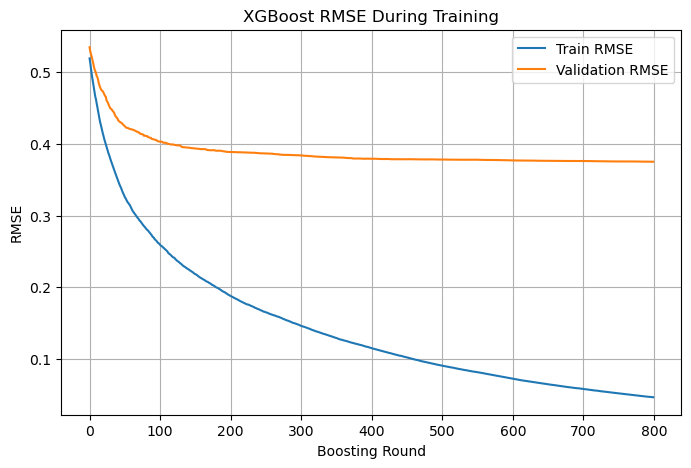

In [36]:
train_rmse = evals_result_best['train']['rmse']
val_rmse   = evals_result_best['val']['rmse']

plt.figure(figsize=(8,5))
plt.plot(train_rmse, label='Train RMSE')
plt.plot(val_rmse,   label='Validation RMSE')
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.title("XGBoost RMSE During Training")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
best_iter = bst_best.best_iteration
print("Best iteration:", best_iter)
print("Best val score:", bst_best.best_score)


Best iteration: 793
Best val score: 0.3749805774312929


In [38]:
y_val_pred_log = bst_best.predict(dval, iteration_range=(0, best_iter + 1))
y_val_true_log = y_val

In [39]:
# Metrics
# Use Log-space metrics
mae_log  = mean_absolute_error(y_val_true_log, y_val_pred_log)
medianea_log = median_absolute_error(y_val_true_log, y_val_pred_log)
mse_log  = mean_squared_error(y_val_true_log, y_val_pred_log)
rmse_log = np.sqrt(mse_log)
r2_log   = r2_score(y_val_true_log, y_val_pred_log)
approx_mape = (np.exp(mae_log) - 1) * 100

print("---- Validation Performance (Log Salary) ----")
print(f"MAE (log):   {mae_log:.4f}")
print(f"MedAE (log): {medianea_log:.4f}")
print(f"RMSE (log):  {rmse_log:.4f}")
print(f"R² (log):    {r2_log:.3f}")
print(f"Approx MAPE: {approx_mape:.1f}%") # Calculates approximate %error in the linera space

---- Validation Performance (Log Salary) ----
MAE (log):   0.1805
MedAE (log): 0.1124
RMSE (log):  0.3750
R² (log):    0.521
Approx MAPE: 19.8%


##### Feature importance

In [40]:
# Examine the feature importance of our features in the best model
importance = bst_best.get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'feature': list(importance.keys()),
    'gain': list(importance.values())
}).sort_values('gain', ascending=False)


In [41]:
importance_df

,feature,gain
3,seniority_level,1.046448
4,job_type,1.036397
28,desc_emb_21,0.972100
5,job_function,0.597605
26,desc_emb_19,0.582272
16,desc_emb_9,0.505497
24,desc_emb_17,0.495430
15,desc_emb_8,0.478492
10,desc_emb_3,0.429234
35,desc_emb_28,0.418574


In [ ]:
# Reminder of number of features used in dtrain (Dmatrix)
num_cols = dtrain.num_col()
print("Number of features used in DMatrix:", num_cols)

Number of features used in DMatrix: 37


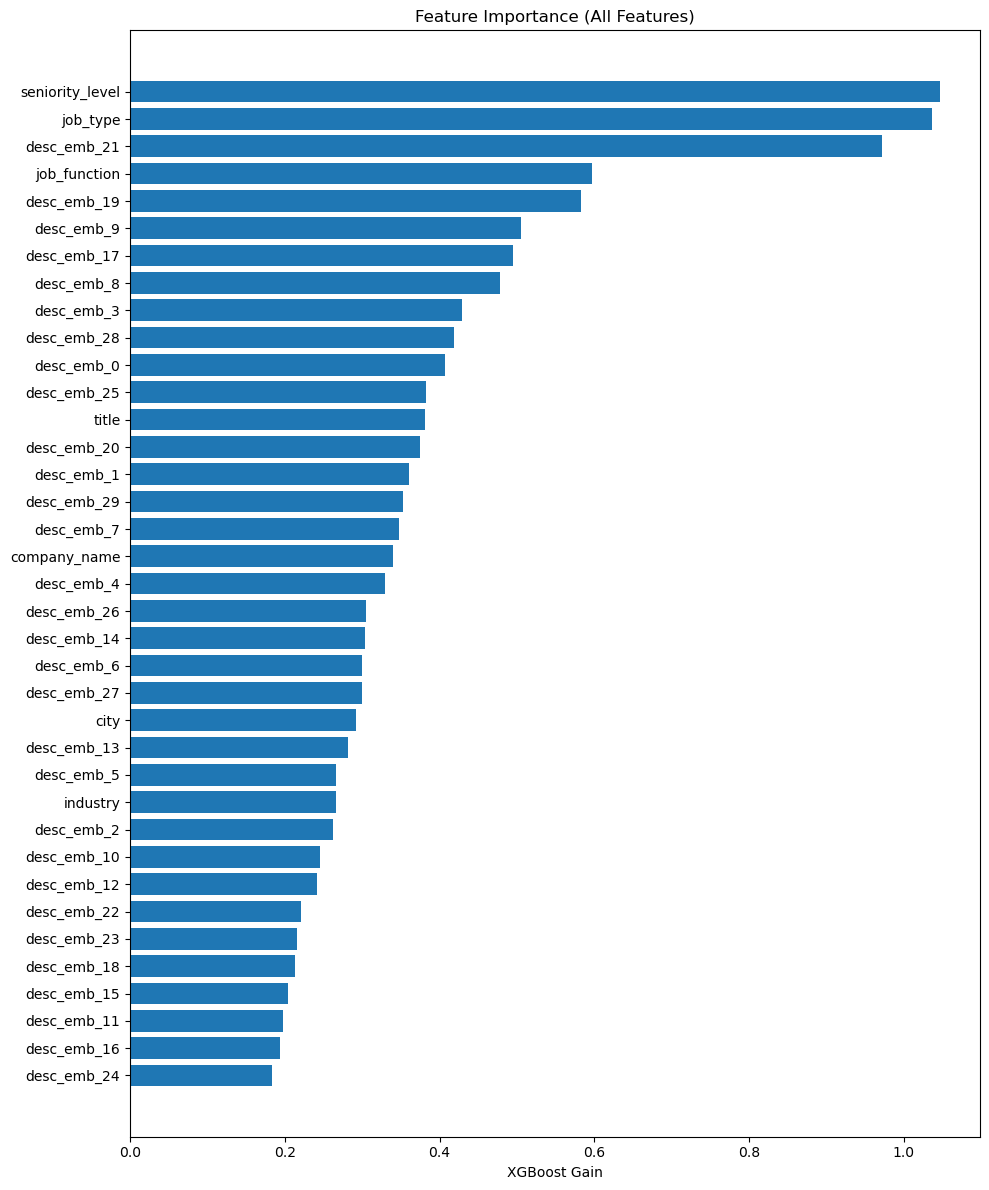

In [46]:
# Plot feature importance for all dimensions
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))
plt.barh(importance_df['feature'], importance_df['gain'])
plt.xlabel("XGBoost Gain")
plt.title("Feature Importance (All Features)")
plt.gca().invert_yaxis()  # highest importance at the top
plt.tight_layout()
plt.show()



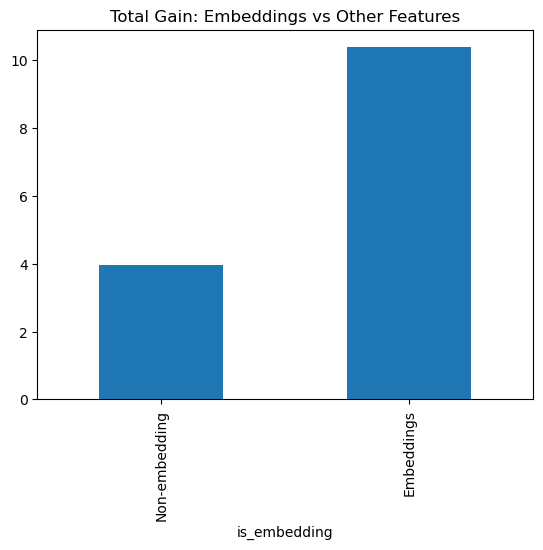

In [ ]:
# Check importance of embeddings vs other features (through cumulative gain)
embed_cols = [col for col in df.columns if col.startswith("desc_emb_")]
importance_df['is_embedding'] = importance_df['feature'].isin(embed_cols)

importance_grouped = (
    importance_df
    .groupby('is_embedding')['gain']
    .sum()
    .rename({True: "Embeddings", False: "Non-embedding"})
)

importance_grouped.plot(kind='bar')
plt.title("Total Gain: Embeddings vs Other Features")
plt.show()


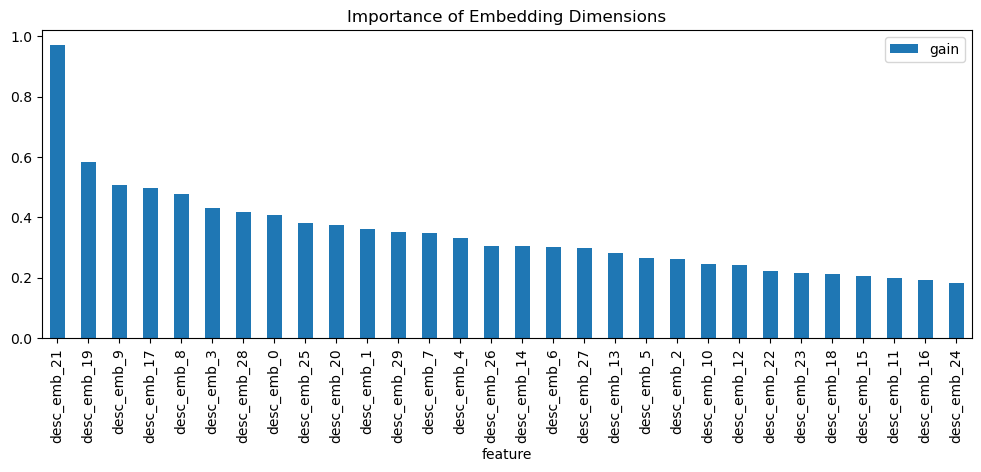

In [45]:
# Plot feature importance for embedding dimensions
embed_importance = importance_df[importance_df['feature'].isin(embed_cols)]
embed_importance = embed_importance.sort_values('gain', ascending=False)

embed_importance.plot(kind='bar', x='feature', y='gain', figsize=(12,4))
plt.title("Importance of Embedding Dimensions")
plt.show()

#### Try regression without the entries that have a range of salaries

In [31]:
df.columns

Index(['offer_id', 'title', 'company_name', 'city', 'seniority_level',
       'job_type', 'job_function', 'industry', 'salary_min', 'salary_max',
       ...
       'desc_emb_291', 'desc_emb_292', 'desc_emb_293', 'desc_emb_294',
       'desc_emb_295', 'desc_emb_296', 'desc_emb_297', 'desc_emb_298',
       'desc_emb_299', 'salary_diff_hour'],
      dtype='object', length=322)

In [32]:
equal_salary_rows = df[df["salary_min_hour"] == df["salary_max_hour"]]

In [34]:
equal_salary_rows.drop(columns=["nltk_lemmas"]).head()

,offer_id,title,company_name,city,seniority_level,job_type,job_function,industry,salary_min,salary_max,salary_unit,salary,searched_position,searched_location,applications,hours_a_week,salary_min_hour,salary_max_hour,salary_avg_hour,salary_avg_hour_log,desc_emb_0,desc_emb_1,desc_emb_2,desc_emb_3,desc_emb_4,desc_emb_5,desc_emb_6,desc_emb_7,desc_emb_8,desc_emb_9,desc_emb_10,desc_emb_11,desc_emb_12,desc_emb_13,desc_emb_14,desc_emb_15,desc_emb_16,desc_emb_17,desc_emb_18,desc_emb_19,desc_emb_20,desc_emb_21,desc_emb_22,desc_emb_23,desc_emb_24,desc_emb_25,desc_emb_26,desc_emb_27,desc_emb_28,desc_emb_29,desc_emb_30,desc_emb_31,desc_emb_32,desc_emb_33,desc_emb_34,desc_emb_35,desc_emb_36,desc_emb_37,desc_emb_38,desc_emb_39,desc_emb_40,desc_emb_41,desc_emb_42,desc_emb_43,desc_emb_44,desc_emb_45,desc_emb_46,desc_emb_47,desc_emb_48,desc_emb_49,desc_emb_50,desc_emb_51,desc_emb_52,desc_emb_53,desc_emb_54,desc_emb_55,desc_emb_56,desc_emb_57,desc_emb_58,desc_emb_59,desc_emb_60,desc_emb_61,desc_emb_62,desc_emb_63,desc_emb_64,desc_emb_65,desc_emb_66,desc_emb_67,desc_emb_68,desc_emb_69,desc_emb_70,desc_emb_71,desc_emb_72,desc_emb_73,desc_emb_74,desc_emb_75,desc_emb_76,desc_emb_77,desc_emb_78,desc_emb_79,desc_emb_80,desc_emb_81,desc_emb_82,desc_emb_83,desc_emb_84,desc_emb_85,desc_emb_86,desc_emb_87,desc_emb_88,desc_emb_89,desc_emb_90,desc_emb_91,desc_emb_92,desc_emb_93,desc_emb_94,desc_emb_95,desc_emb_96,desc_emb_97,desc_emb_98,desc_emb_99,desc_emb_100,desc_emb_101,desc_emb_102,desc_emb_103,desc_emb_104,desc_emb_105,desc_emb_106,desc_emb_107,desc_emb_108,desc_emb_109,desc_emb_110,desc_emb_111,desc_emb_112,desc_emb_113,desc_emb_114,desc_emb_115,desc_emb_116,desc_emb_117,desc_emb_118,desc_emb_119,desc_emb_120,desc_emb_121,desc_emb_122,desc_emb_123,desc_emb_124,desc_emb_125,desc_emb_126,desc_emb_127,desc_emb_128,desc_emb_129,desc_emb_130,desc_emb_131,desc_emb_132,desc_emb_133,desc_emb_134,desc_emb_135,desc_emb_136,desc_emb_137,desc_emb_138,desc_emb_139,desc_emb_140,desc_emb_141,desc_emb_142,desc_emb_143,desc_emb_144,desc_emb_145,desc_emb_146,desc_emb_147,desc_emb_148,desc_emb_149,desc_emb_150,desc_emb_151,desc_emb_152,desc_emb_153,desc_emb_154,desc_emb_155,desc_emb_156,desc_emb_157,desc_emb_158,desc_emb_159,desc_emb_160,desc_emb_161,desc_emb_162,desc_emb_163,desc_emb_164,desc_emb_165,desc_emb_166,desc_emb_167,desc_emb_168,desc_emb_169,desc_emb_170,desc_emb_171,desc_emb_172,desc_emb_173,desc_emb_174,desc_emb_175,desc_emb_176,desc_emb_177,desc_emb_178,desc_emb_179,desc_emb_180,desc_emb_181,desc_emb_182,desc_emb_183,desc_emb_184,desc_emb_185,desc_emb_186,desc_emb_187,desc_emb_188,desc_emb_189,desc_emb_190,desc_emb_191,desc_emb_192,desc_emb_193,desc_emb_194,desc_emb_195,desc_emb_196,desc_emb_197,desc_emb_198,desc_emb_199,desc_emb_200,desc_emb_201,desc_emb_202,desc_emb_203,desc_emb_204,desc_emb_205,desc_emb_206,desc_emb_207,desc_emb_208,desc_emb_209,desc_emb_210,desc_emb_211,desc_emb_212,desc_emb_213,desc_emb_214,desc_emb_215,desc_emb_216,desc_emb_217,desc_emb_218,desc_emb_219,desc_emb_220,desc_emb_221,desc_emb_222,desc_emb_223,desc_emb_224,desc_emb_225,desc_emb_226,desc_emb_227,desc_emb_228,desc_emb_229,desc_emb_230,desc_emb_231,desc_emb_232,desc_emb_233,desc_emb_234,desc_emb_235,desc_emb_236,desc_emb_237,desc_emb_238,desc_emb_239,desc_emb_240,desc_emb_241,desc_emb_242,desc_emb_243,desc_emb_244,desc_emb_245,desc_emb_246,desc_emb_247,desc_emb_248,desc_emb_249,desc_emb_250,desc_emb_251,desc_emb_252,desc_emb_253,desc_emb_254,desc_emb_255,desc_emb_256,desc_emb_257,desc_emb_258,desc_emb_259,desc_emb_260,desc_emb_261,desc_emb_262,desc_emb_263,desc_emb_264,desc_emb_265,desc_emb_266,desc_emb_267,desc_emb_268,desc_emb_269,desc_emb_270,desc_emb_271,desc_emb_272,desc_emb_273,desc_emb_274,desc_emb_275,desc_emb_276,desc_emb_277,desc_emb_278,desc_emb_279,desc_emb_280,desc_emb_281,desc_emb_282,desc_emb_283,desc_emb_284,desc_emb_285,desc_emb_286,desc_emb_287,desc_emb_288,desc_emb_289,desc_emb_290,desc_emb_291,desc_emb_292,desc_emb_293,desc_emb_294,desc_emb_295,desc_emb_2

In [35]:
len(equal_salary_rows)

43

##### Try with the job titles

In [37]:
df_titles= pd.read_csv("role_family_mapping.csv")

In [38]:
df_titles.columns

Index(['title', 'role_family'], dtype='object')

In [45]:
df["title_family"] = df_titles["role_family"]

In [46]:
df.columns

Index(['offer_id', 'title', 'company_name', 'city', 'state_code',
       'seniority_level', 'job_type', 'job_function', 'industry',
       'description', 'salary_min', 'salary_max', 'salary_unit', 'salary',
       'searched_position', 'searched_location', 'applications', 'nltk_lemmas',
       'hours_a_week', 'salary_min_hour', 'salary_max_hour', 'salary_avg_hour',
       'salary_avg_hour_log', 'title_family'],
      dtype='object')

In [48]:
categorical_cols = [
    'title_family'
]

# Create a copy of  to encode categorical variables
df_family=df.copy()
for col in categorical_cols:
    df_family[col] = df_family[col].astype("category").cat.codes

In [51]:
# Separate dataset in with and without salary
has_salary = df_family["salary_min"].notna() | df_family["salary_max"].notna()
df_train_val = df_family[has_salary].copy()
df_test = df_family[~has_salary].copy()

In [50]:
# LEave in X only the feature columns we are interested in
categorical_cols = [
    "title_family",
    "company_name",
    "city",
    "seniority_level",
    "job_type",
    "job_function",
    "industry"
]

# Generate embedding column names: desc_emb_0 to desc_emb_299
embedding_cols = [f"desc_emb_{i}" for i in range(300)]

# Union of both lists
feature_cols = categorical_cols + embedding_cols

# Keep only feature columns in X
X = df_train_val[feature_cols]
# Set as target the log avg salary
y = df_train_val["salary_avg_hour_log"]
# y = df_train_val["salary_avg_hour_log"] # To try predicting the real salary instead of log

KeyError: "['desc_emb_0', 'desc_emb_1', 'desc_emb_2', 'desc_emb_3', 'desc_emb_4', 'desc_emb_5', 'desc_emb_6', 'desc_emb_7', 'desc_emb_8', 'desc_emb_9', 'desc_emb_10', 'desc_emb_11', 'desc_emb_12', 'desc_emb_13', 'desc_emb_14', 'desc_emb_15', 'desc_emb_16', 'desc_emb_17', 'desc_emb_18', 'desc_emb_19', 'desc_emb_20', 'desc_emb_21', 'desc_emb_22', 'desc_emb_23', 'desc_emb_24', 'desc_emb_25', 'desc_emb_26', 'desc_emb_27', 'desc_emb_28', 'desc_emb_29', 'desc_emb_30', 'desc_emb_31', 'desc_emb_32', 'desc_emb_33', 'desc_emb_34', 'desc_emb_35', 'desc_emb_36', 'desc_emb_37', 'desc_emb_38', 'desc_emb_39', 'desc_emb_40', 'desc_emb_41', 'desc_emb_42', 'desc_emb_43', 'desc_emb_44', 'desc_emb_45', 'desc_emb_46', 'desc_emb_47', 'desc_emb_48', 'desc_emb_49', 'desc_emb_50', 'desc_emb_51', 'desc_emb_52', 'desc_emb_53', 'desc_emb_54', 'desc_emb_55', 'desc_emb_56', 'desc_emb_57', 'desc_emb_58', 'desc_emb_59', 'desc_emb_60', 'desc_emb_61', 'desc_emb_62', 'desc_emb_63', 'desc_emb_64', 'desc_emb_65', 'desc_emb_66', 'desc_emb_67', 'desc_emb_68', 'desc_emb_69', 'desc_emb_70', 'desc_emb_71', 'desc_emb_72', 'desc_emb_73', 'desc_emb_74', 'desc_emb_75', 'desc_emb_76', 'desc_emb_77', 'desc_emb_78', 'desc_emb_79', 'desc_emb_80', 'desc_emb_81', 'desc_emb_82', 'desc_emb_83', 'desc_emb_84', 'desc_emb_85', 'desc_emb_86', 'desc_emb_87', 'desc_emb_88', 'desc_emb_89', 'desc_emb_90', 'desc_emb_91', 'desc_emb_92', 'desc_emb_93', 'desc_emb_94', 'desc_emb_95', 'desc_emb_96', 'desc_emb_97', 'desc_emb_98', 'desc_emb_99', 'desc_emb_100', 'desc_emb_101', 'desc_emb_102', 'desc_emb_103', 'desc_emb_104', 'desc_emb_105', 'desc_emb_106', 'desc_emb_107', 'desc_emb_108', 'desc_emb_109', 'desc_emb_110', 'desc_emb_111', 'desc_emb_112', 'desc_emb_113', 'desc_emb_114', 'desc_emb_115', 'desc_emb_116', 'desc_emb_117', 'desc_emb_118', 'desc_emb_119', 'desc_emb_120', 'desc_emb_121', 'desc_emb_122', 'desc_emb_123', 'desc_emb_124', 'desc_emb_125', 'desc_emb_126', 'desc_emb_127', 'desc_emb_128', 'desc_emb_129', 'desc_emb_130', 'desc_emb_131', 'desc_emb_132', 'desc_emb_133', 'desc_emb_134', 'desc_emb_135', 'desc_emb_136', 'desc_emb_137', 'desc_emb_138', 'desc_emb_139', 'desc_emb_140', 'desc_emb_141', 'desc_emb_142', 'desc_emb_143', 'desc_emb_144', 'desc_emb_145', 'desc_emb_146', 'desc_emb_147', 'desc_emb_148', 'desc_emb_149', 'desc_emb_150', 'desc_emb_151', 'desc_emb_152', 'desc_emb_153', 'desc_emb_154', 'desc_emb_155', 'desc_emb_156', 'desc_emb_157', 'desc_emb_158', 'desc_emb_159', 'desc_emb_160', 'desc_emb_161', 'desc_emb_162', 'desc_emb_163', 'desc_emb_164', 'desc_emb_165', 'desc_emb_166', 'desc_emb_167', 'desc_emb_168', 'desc_emb_169', 'desc_emb_170', 'desc_emb_171', 'desc_emb_172', 'desc_emb_173', 'desc_emb_174', 'desc_emb_175', 'desc_emb_176', 'desc_emb_177', 'desc_emb_178', 'desc_emb_179', 'desc_emb_180', 'desc_emb_181', 'desc_emb_182', 'desc_emb_183', 'desc_emb_184', 'desc_emb_185', 'desc_emb_186', 'desc_emb_187', 'desc_emb_188', 'desc_emb_189', 'desc_emb_190', 'desc_emb_191', 'desc_emb_192', 'desc_emb_193', 'desc_emb_194', 'desc_emb_195', 'desc_emb_196', 'desc_emb_197', 'desc_emb_198', 'desc_emb_199', 'desc_emb_200', 'desc_emb_201', 'desc_emb_202', 'desc_emb_203', 'desc_emb_204', 'desc_emb_205', 'desc_emb_206', 'desc_emb_207', 'desc_emb_208', 'desc_emb_209', 'desc_emb_210', 'desc_emb_211', 'desc_emb_212', 'desc_emb_213', 'desc_emb_214', 'desc_emb_215', 'desc_emb_216', 'desc_emb_217', 'desc_emb_218', 'desc_emb_219', 'desc_emb_220', 'desc_emb_221', 'desc_emb_222', 'desc_emb_223', 'desc_emb_224', 'desc_emb_225', 'desc_emb_226', 'desc_emb_227', 'desc_emb_228', 'desc_emb_229', 'desc_emb_230', 'desc_emb_231', 'desc_emb_232', 'desc_emb_233', 'desc_emb_234', 'desc_emb_235', 'desc_emb_236', 'desc_emb_237', 'desc_emb_238', 'desc_emb_239', 'desc_emb_240', 'desc_emb_241', 'desc_emb_242', 'desc_emb_243', 'desc_emb_244', 'desc_emb_245', 'desc_emb_246', 'desc_emb_247', 'desc_emb_248', 'desc_emb_249', 'desc_emb_250', 'desc_emb_251', 'desc_emb_252', 'desc_emb_253', 'desc_emb_254', 'desc_emb_255', 'desc_emb_256', 'desc_emb_257', 'desc_emb_258', 'desc_emb_259', 'desc_emb_260', 'desc_emb_261', 'desc_emb_262', 'desc_emb_263', 'desc_emb_264', 'desc_emb_265', 'desc_emb_266', 'desc_emb_267', 'desc_emb_268', 'desc_emb_269', 'desc_emb_270', 'desc_emb_271', 'desc_emb_272', 'desc_emb_273', 'desc_emb_274', 'desc_emb_275', 'desc_emb_276', 'desc_emb_277', 'desc_emb_278', 'desc_emb_279', 'desc_emb_280', 'desc_emb_281', 'desc_emb_282', 'desc_emb_283', 'desc_emb_284', 'desc_emb_285', 'desc_emb_286', 'desc_emb_287', 'desc_emb_288', 'desc_emb_289', 'desc_emb_290', 'desc_emb_291', 'desc_emb_292', 'desc_emb_293', 'desc_emb_294', 'desc_emb_295', 'desc_emb_296', 'desc_emb_297', 'desc_emb_298', 'desc_emb_299'] not in index"

#### Evaluation over all train+val

In [45]:
# Re-run as the variables X and y must have been modified after initial definition and get error
# Keep only feature columns in X
X = df_train_val[feature_cols]
# Set as target the log avg salary
y = df_train_val["salary_avg_hour_log"]

In [46]:
# Train the model over the full labeled dataset
X_full = X.values             # df_train_val[feature_cols]
y_full_log = y.values            # df_train_val["salary_avg_year_log"]

"""print("Right after assignment:")
print(y_full_log[:10])
print(y.values[:10])"""

dtrain_full = xgb.DMatrix(X_full, label=y_full_log)

# Use best_iter + 1 trees, no early stopping (we already validated)
bst_final = xgb.train(
    params=params_best,
    dtrain=dtrain_full,
    num_boost_round=best_iter + 1,
    evals=[(dtrain_full, "train")],
    verbose_eval=50,
)

print("Final model trained with", best_iter + 1, "trees.")


[0]	train-rmse:0.52582
[50]	train-rmse:0.37375
[100]	train-rmse:0.29786
[150]	train-rmse:0.25138
[200]	train-rmse:0.21672
[250]	train-rmse:0.19060
[300]	train-rmse:0.16893
[350]	train-rmse:0.15109
[400]	train-rmse:0.13483
[450]	train-rmse:0.12087
[500]	train-rmse:0.10876
[550]	train-rmse:0.09892
[600]	train-rmse:0.08932
[650]	train-rmse:0.08060
[700]	train-rmse:0.07280
[750]	train-rmse:0.06583
[799]	train-rmse:0.05982
Final model trained with 800 trees.


#### Prediction

In [ ]:
# Missing:ensure which transformations were applied to X_test before predicting

In [146]:
# Build test feature matrix with the same columns
X_test = df_test[feature_cols].copy()
dtest  = xgb.DMatrix(X_test)

# Predict in log space
y_test_pred_log = bst_final.predict(dtest)

# Convert back to yearly salary
y_test_pred_year = np.exp(y_test_pred_log)

# Attach to df_test
df_test["pred_salary_avg_year_log"] = y_test_pred_log
df_test["pred_salary_avg_year"]     = y_test_pred_year

df_test[["pred_salary_avg_year"]].head()


,pred_salary_avg_year
1,77203.789062
2,55070.183594
3,60832.625000
6,60832.625000
9,95252.984375


In [ ]:
# Perform over df_test the transformations we did over df_train_val
# LEave in X only the feature columns we are interested in
categorical_cols = [
    "title",
    "company_name",
    "city",
    "seniority_level",
    "job_type",
    "job_function",
    "industry"
]

# Generate embedding column names: desc_emb_0 to desc_emb_299
embedding_cols = [f"desc_emb_{i}" for i in range(300)]

# Union of both lists
feature_cols = categorical_cols + embedding_cols

# Keep only feature columns in X
X_test = df_test[feature_cols]
# Set as target the log avg salary
y_test = df_test["salary_avg_year_log"]
# y_test = df_test["salary_avg_year"] # To try predicting the real salary instead of log

In [94]:
dtest = xgb.DMatrix(X_test)

In [95]:
y_test_pred_log = bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))


In [96]:
y_test_pred_year = np.exp(y_test_pred_log)

In [98]:
y_test_pred_year[:20]

array([ 75074.51 ,  60179.84 ,  59749.28 ,  59749.28 , 101151.625,
       166183.1  , 174647.03 , 149247.83 ,  93899.53 , 172768.8  ,
       105643.28 , 155959.22 , 214936.34 , 162036.95 , 123014.26 ,
       189970.83 , 172083.42 , 144138.31 ,  57662.883, 162140.2  ],
      dtype=float32)

In [60]:
# Convert back to original salary scale (undo log)
y_val_true = np.expm1(y_val)
y_val_pred = np.expm1(y_val_pred_log)


In [61]:
mae = mean_absolute_error(y_val_true, y_val_pred)
mse = mean_squared_error(y_val_true, y_val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val_true, y_val_pred)

print(f"Validation MAE:  {mae:,.0f}")
print(f"Validation RMSE: {rmse:,.0f}")
print(f"Validation R²:   {r2:.3f}")

Validation MAE:  127,791
Validation RMSE: 3,612,063
Validation R²:   0.608


In [ ]:
# Need to run once we have to full dataset, with converted salaries and WE for the description

#### Final code parsing Linkedin json

In [ ]:
# Purpose of the notebook: parse json schema returned by the Linkedin scraper
# OBS: not finished to parse:
# Libraries to use
# Standard libraries
import pandas as pd
pd.set_option("display.max_columns", None)   # no column truncation
pd.set_option("display.max_rows", None)      # no row truncation
pd.set_option("display.width", None)         # no line-wrapping
pd.set_option("display.max_colwidth", None)
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
# Specific libraries
import json
from pathlib import Path
import re

# Create the mapping dictionary from text name of state to state code. OBS: not needed for now
state_map = {
    "california": "CA"
}

# Recover file name
file_solvang = "EngineerJobs_ByLocation_Solvang.json"
path = Path(file_solvang)

with path.open("r", encoding="utf-8") as f:
    data = json.load(f)               # expects a list[dict]

# If it's a single dict, make it a list
if isinstance(data, dict):
    data = [data]

# Flatten nested fields (company.name -> company_name)
df = pd.json_normalize(data, sep=".")

# Create offer ID using the index (checked that it is unique)
df["offer_id"] = df.index

# EXTRACT CRITERIA INFORMATION INTO COLUMNS
# Explode the criteria column: extract the content of the dict in four columns
df["criteria_dict"] = df["criteria"].apply(
    lambda lst: {d["name"]: d["value"] for d in lst}
)
criteria_expanded = df["criteria_dict"].apply(pd.Series)

df = pd.concat([df, criteria_expanded], axis=1)
df = df.drop(columns=["criteria", "criteria_dict"])

# RENAME AND REORDER COLUMNS
# Rename columns to have the same naming criteria
df = df.rename(columns={
    "company.name": "company_name",
    "company.url": "company_url",
    "Seniority level": "seniority_level",
    "Employment type": "job_type",
    "Job function": "job_function",
    "Industries": "industry"
})

# Reorder the cols as we want them
"""ordered = ['offer_id', "title", "company_name", "location", "salary",
           "description", "url", 'criteria', "seniority_level",'job_type',
           'job_function','industry','searched_position', 'searched_location',
           'applications', 'company_url']
df=df[ordered]"""

# PARSE SALARY INFORMATION
# Ensure None are numpy NaN
df["salary"] = df["salary"].replace([None, "None", ""], np.nan)

# User regular expressions to extract the information we want from the current salary column
# We define first dicts that contain the unit patterns we want to detect
_unit_patterns = [
    (r"\b(per|an|a)\s+hour\b|/hour|/hr|\bhr\b|\bhour\b", "hour"),
    (r"\b(per|an|a)\s+year\b|/year|\byr\b|\byear\b|\bannum\b", "year"),
    (r"\b(per|an|a)\s+month\b|/month|\bmo\b|\bmonth\b", "month"),
    (r"\b(per|an|a)\s+week\b|/week|\bwk\b|\bweek\b", "week"),
    # Did not see for now salaries by day, otherwise, add
]
# Same for the digits
_num_pattern = re.compile(
    r"\$?\s*([0-9]{1,3}(?:,[0-9]{3})*(?:\.[0-9]+)?|[0-9]+(?:\.[0-9]+)?)"
)

# Function to detect the unit of time the salary is given in
def _detect_unit(text_lower):
    for pattern, unit in _unit_patterns:
        if re.search(pattern, text_lower):
            return unit
    return pd.NA

# Function to parse the content of the current salary column
def parse_salary_cell(s):
    """
    Returns (min_val, max_val, unit) where min/max are floats (NaN if not found),
    and unit in {'hour','month','year','week', NA}.
    """
    if pd.isna(s):
        return np.nan, np.nan, pd.NA
    # Remove from the string whitespaces and convert to lower case
    txt = str(s).strip()
    txt_lower = txt.lower()

    # Find all numeric parts in the string
    nums = [float(n.replace(",", "")) for n in _num_pattern.findall(txt)]
    if not nums:
        return np.nan, np.nan, _detect_unit(txt_lower)

    # If we recover one number, assign to both min and max
    # If we recover two numbers, assing as corresponds to min and max
    if len(nums) >= 2:
        low, high = sorted(nums[:2])
    else:
        low = high = nums[0]

    unit = _detect_unit(txt_lower)
    return low, high, unit

# Apply to the column and create the new columns
parsed = df["salary"].apply(parse_salary_cell)
df[["salary_min", "salary_max", "salary_unit"]] = pd.DataFrame(parsed.tolist(), index=df.index)

# PARSE LOCATION INFORMATION
# Extract from location the city and the US state
# Initialize columns
df["city"] = pd.NA
df["state"] = pd.NA

# Split location first
splits = df["location"].str.split(",")

# Compute len per row
len_location = splits.str.len()
# In first Linkedin json only get location with 2 splits, but include the rest of the code in case there are entries
# with only one split as in Indeed data
# If len_location == 1
mask1 = len_location == 1
df.loc[mask1, "city"] = pd.NA
df.loc[mask1, "state"] = splits.str[-1]
# Over this recovered state name, apply the mapping to encode the state code
df["state"] = (
    df["state"]
    .str.lower()
    .replace(state_map, regex=False)
)
# If len_location > 1
mask2 = len_location > 1
df.loc[mask2, "city"] = splits.str[-2]
df.loc[mask2, "state"] = splits.str[-1]
# Need to remove the postal code
df["state_code"] = df["state"].str.split().str[0]

# CODE TO TREAT ENTRIES IN WHICH 'salary' DOES NOT CONTAIN SALARY INFORMATION
# Try to capture the entries where salary is not None or contains a $ -> these are entries where there is
# another information in salary. May be usueful.
df_no_dollar = df[
    df["salary"].apply(lambda x: isinstance(x, str)) &
    ~df["salary"].str.contains(r"\$", na=False)
].copy()

df_no_dollar = df_no_dollar[["offer_id", "salary"]].rename(
    columns={"salary": "useful_type"}
)
len_df_no_dollar = len(df_no_dollar)
print(f"Number of entries with no salary information in 'salary' column: {len_df_no_dollar}")

# If len_df_no_dollar is not 0
if len_df_no_dollar != 0:
    df = df.merge(df_no_dollar, on="offer_id", how="left")
    # Now extract information from job_type: eliminate 'Job type '
    df["job_type"] = df["job_type"].str.replace("Job type ", "", regex=False)

    # Compare job_type and useful_type (information previously extracted from 'salary'
    # when its content is not in fact a salary). Create a col to store the comparison.
    df["job_vs_useful_match"] = None

    mask = df["useful_type"].notna()
    df.loc[mask, "job_vs_useful_match"] = (
        df.loc[mask, "job_type"] == df.loc[mask, "useful_type"]
    )
    # Print the values of 'job_vs_useful_match'. If all True and the same number than
    # "Number of entries with no salary information in 'salary' column: ", the information in
    # useful_type is the same than the one contained in "job_type".
    counts = df.value_counts("job_vs_useful_match")[True]

    # Print the values of 'job_vs_useful_match'. If all True and the same number than
    # "Number of entries with no salary information in 'salary' column: ", the information in
    # useful_type is the same than the one contained in "job_type".
    counts = df.value_counts("job_vs_useful_match")[True]
    print("Number of entries with the same content in useful_type than in job_type: ", counts)
    print("If same number, columns useful_type and job_vs_useful_match can be dropped from df")

# SAVE URL to OFFER_ID AND DROP
# Before dropping 'url', store csv with offer_id, url in case it is useful in the future.
df[["offer_id", "url"]].to_csv("offer_id_url_Linkedin.csv", index=False)

# DROP, REORDER AND STORE DF into CSV
# Columns determined to be non-useful are dropped: url, company_url, pay
df.drop(columns=["url", "company_url", "state", "location"], inplace=True)

# Reorder the df into our preferred order
print("Num cols before reordering: ", len(df.columns))
ordered = ['offer_id', "title", "company_name", 'city', 'state_code','seniority_level',
           'job_type', 'job_function', 'industry',
           "description", 'salary_min', 'salary_max', 'salary_unit',"salary",
           'searched_position', 'searched_location', 'applications']
print("Num cols after reordering: ", len(ordered))

df = df[ordered]
# To save
file_name= "jobs_linkedin_solvang.csv"
df.to_csv(file_name, index=False)
print(f"Data has been saved to file: {file_name}")

Number of entries with no salary information in 'salary' column: 0
Num cols before reordering:  17
Num cols after reordering:  17
Data has been saved to file: jobs_linkedin_solvang.csv


In [ ]:
df.columns

Index(['offer_id', 'title', 'company_name', 'city', 'state_code',
       'seniority_level', 'job_type', 'job_function', 'industry',
       'description', 'salary_min', 'salary_max', 'salary_unit', 'salary',
       'searched_position', 'searched_location', 'applications'],
      dtype='object')

In [ ]:
df.drop(columns=['description']).head()

,offer_id,title,company_name,city,state_code,seniority_level,job_type,job_function,industry,salary_min,salary_max,salary_unit,salary,searched_position,searched_location,applications
0,0,Software Developer,Tecolote Research,Goleta,CA,Entry level,Full-time,Information Technology,Business Consulting and Services and Space Research and Technology,55000.0,70000.0,year,"$55,000.00/yr - $70,000.00/yr",Software Engineer,Solvang,Over 200 applicants
1,1,Software Engineer,Teledyne Technologies Incorporated,Goleta,CA,Mid-Senior level,Full-time,Engineering and Information Technology,Software Development,NaN,NaN,<NA>,NaN,Software Engineer,Solvang,Over 200 applicants
2,2,Software Engineer,Digital Prospectors,Goleta,CA,Mid-Senior level,Contract,Information Technology and Manufacturing,"Software Development, Defense and Space Manufacturing, and Manufacturing",70.0,80.0,hour,$70.00/hr - $80.00/hr,Software Engineer,Solvang,90 applicants
3,3,Java Spring Microservice,Litmus7,Goleta,CA,Mid-Senior level,Full-time,Engineering and Information Technology,IT Services and IT Consulting,NaN,NaN,<NA>,NaN,Software Engineer,Solvang,Over 200 applicants
4,4,Software Engineer,Toyon Research Corporation,Goleta,CA,Mid-Senior level,Full-time,Engineering and Information Technology,Defense and Space Manufacturing,90000.0,140000.0,year,"$90,000.00/yr - $140,000.00/yr",Software Engineer,Solvang,135 applicants


In [ ]:
# Purpose of the notebook: parse json schema returned by the indeed scraper
# OBS: not finished to parse: 'shift_schedule', 'work_setting'
# Libraries to use
# Standard libraries
import pandas as pd
pd.set_option("display.max_columns", None)   # no column truncation
pd.set_option("display.max_rows", None)      # no row truncation
pd.set_option("display.width", None)         # no line-wrapping
pd.set_option("display.max_colwidth", None)
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
# Specific libraries
import json
from pathlib import Path
import re

# Create the mapping dictionary from text name of state to state code
state_map = {
    "california": "CA"
}

path = Path("indeed_jobs.json")

with path.open("r", encoding="utf-8") as f:
    data = json.load(f)               # expects a list[dict]

# If it's a single dict, make it a list
if isinstance(data, dict):
    data = [data]

# Flatten nested fields (company.name -> company_name)
df = pd.json_normalize(data, sep=".")

# Create offer ID using the index (checked that it is unique)
df["offer_id"] = df.index
# Rename columns to have the same naming criteria
df = df.rename(columns={
    "company.name": "company_name",
    "company.url": "company_url",
    "criteria.Pay": "pay",
    "criteria.Job type": "job_type",
    "criteria.Shift and schedule": "shift_schedule",
    "criteria.Work setting": "work_setting"
})
# Reorder
cols_order=["offer_id", "title", "company_name", "location", "salary", 'pay', 'job_type', 'shift_schedule', 'work_setting', "description","url", "company_url"]
df=df[cols_order]

# Ensure core columns exist even if missing in some entries
for col in ["url", "title", "company_name", "company_url", "location", "salary", "description"]:
    if col not in df.columns:
        df[col] = pd.NA

# Ensure None are numpy NaN
df["salary"] = df["salary"].replace([None, "None", ""], np.nan)

# User regular expressions to extract the information we want from the current salary column
# We define first dicts that contain the unit patterns we want to detect
_unit_patterns = [
    (r"\b(per|an|a)\s+hour\b|/hour|/hr|\bhr\b|\bhour\b", "hour"),
    (r"\b(per|an|a)\s+year\b|/year|\byr\b|\byear\b|\bannum\b", "year"),
    (r"\b(per|an|a)\s+month\b|/month|\bmo\b|\bmonth\b", "month"),
    (r"\b(per|an|a)\s+week\b|/week|\bwk\b|\bweek\b", "week"),
    # Did not see for now salaries by day, otherwise, add
]
# Same for the digits
_num_pattern = re.compile(
    r"\$?\s*([0-9]{1,3}(?:,[0-9]{3})*(?:\.[0-9]+)?|[0-9]+(?:\.[0-9]+)?)"
)

# Function to detect the unit of time the salary is given in
def _detect_unit(text_lower):
    for pattern, unit in _unit_patterns:
        if re.search(pattern, text_lower):
            return unit
    return pd.NA

# Function to parse the content of the current salary column
def parse_salary_cell(s):
    """
    Returns (min_val, max_val, unit) where min/max are floats (NaN if not found),
    and unit in {'hour','month','year','week', NA}.
    """
    if pd.isna(s):
        return np.nan, np.nan, pd.NA
    # Remove from the string whitespaces and convert to lower case
    txt = str(s).strip()
    txt_lower = txt.lower()

    # Find all numeric parts in the string
    nums = [float(n.replace(",", "")) for n in _num_pattern.findall(txt)]
    if not nums:
        return np.nan, np.nan, _detect_unit(txt_lower)

    # If we recover one number, assign to both min and max
    # If we recover two numbers, assing as corresponds to min and max
    if len(nums) >= 2:
        low, high = sorted(nums[:2])
    else:
        low = high = nums[0]

    unit = _detect_unit(txt_lower)
    return low, high, unit

# Apply to the column and create the new columns
parsed = df["salary"].apply(parse_salary_cell)
df[["salary_min", "salary_max", "salary_unit"]] = pd.DataFrame(parsed.tolist(), index=df.index)

# Extract from location the city and the US state
# Initialize columns
df["city"] = pd.NA
df["state"] = pd.NA

# Split location first
splits = df["location"].str.split(",")

# Compute len per row
len_location = splits.str.len()

# If len_location == 1
mask1 = len_location == 1
df.loc[mask1, "city"] = pd.NA
df.loc[mask1, "state"] = splits.str[-1]
# Over this recovered state name, apply the mapping to encode the state code
df["state"] = (
    df["state"]
    .str.lower()
    .replace(state_map, regex=False)
)

# If len_location > 1
mask2 = len_location > 1
df.loc[mask2, "city"] = splits.str[-2]
df.loc[mask2, "state"] = splits.str[-1]

# df.drop(columns=["prov"], inplace=True)
# Need to remove the postal code
df["state_code"] = df["state"].str.split().str[0]

# Columns determined to be non-useful are dropped: url, company_url, pay
# However, store csv with offer_id, url in case it is useful in the future.
df[["offer_id", "url"]].to_csv("offer_id_url.csv", index=False)

# Drop
df.drop(columns=["url", "company_url", "state"], inplace=True)

# Try to capture the entries where salary is not None or contains a $ -> these are entries where there is
# another information in salary. May be usueful.
df_no_dollar = df[
    df["salary"].apply(lambda x: isinstance(x, str)) &
    ~df["salary"].str.contains(r"\$", na=False)
].copy()

df_no_dollar = df_no_dollar[["offer_id", "salary"]].rename(
    columns={"salary": "useful_type"}
)
print(f"Number of entries with no salary information in 'salary' column: {len(df_no_dollar)}")
df = df.merge(df_no_dollar, on="offer_id", how="left")

# Now extract information from job_type: eliminate 'Job type '
df["job_type"] = df["job_type"].str.replace("Job type ", "", regex=False)

# Compare job_type and useful_type (information previously extracted from 'salary'
# when its content is not in fact a salary). Create a col to store the comparison.
df["job_vs_useful_match"] = None

mask = df["useful_type"].notna()
df.loc[mask, "job_vs_useful_match"] = (
    df.loc[mask, "job_type"] == df.loc[mask, "useful_type"]
)
# Print the values of 'job_vs_useful_match'. If all True and the same number than
# "Number of entries with no salary information in 'salary' column: ", the information in
# useful_type is the same than the one contained in "job_type".
counts = df.value_counts("job_vs_useful_match")[True]
print("Number of entries with the same content in useful_type than in job_type: ", counts)
print("If same number, columns useful_type and job_vs_useful_match can be dropped from df")
# Then, if needed, drop 'useful_type' and 'job_vs_useful_match' columns.
# ------------------------------------------------------------------------------
# MISSING CODE YET
# Parse: 'shift_schedule', 'work_setting'
# ------------------------------------------------------------------------------
# Last drop of unnecessary columns: location
df.drop(columns=["location", 'shift_schedule', 'work_setting'], inplace=True)

# Reorder the df into our preferred order
ordered = ['offer_id', "title", "company_name", 'city', 'state_code','job_type', "description", 'salary_min', 'salary_max', 'salary_unit',"salary",'useful_type', 'job_vs_useful_match']

df = df[ordered]
# To save
file_name= "jobs_indeed.csv"
df.to_csv(file_name, index=False)
print(f"Data has been saved to file: {file_name}")

Number of entries with no salary information in 'salary' column: 9
Number of entries with the same content in useful_type than in job_type:  9
If same number, columns useful_type and job_vs_useful_match can be dropped from df
Data has been saved to file: jobs_indeed.csv


In [ ]:
# # Purpose of the notebook: parse json schema returned by the indeed scraper
# OBS: not finished to parse several columns: Criteria.Pay
# Libraries to use
# Standard libraries
import pandas as pd
pd.set_option("display.max_columns", None)   # no column truncation
pd.set_option("display.max_rows", None)      # no row truncation
pd.set_option("display.width", None)         # no line-wrapping
pd.set_option("display.max_colwidth", None)
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
# Specific libraries
import json
from pathlib import Path
import re

# Create the mapping dictionary from text name of state to state code
state_map = {
    "california": "CA"
}

path = Path("indeed_jobs.json")

with path.open("r", encoding="utf-8") as f:
    data = json.load(f)               # expects a list[dict]

# If it's a single dict, make it a list
if isinstance(data, dict):
    data = [data]

# Flatten nested fields (company.name -> company_name)
df = pd.json_normalize(data, sep=".")

# Create offer ID using the index (checked that it is unique)
df["offer_id"] = df.index
# Rename columns to have the same naming criteria
df = df.rename(columns={
    "company.name": "company_name",
    "company.url": "company_url",
    "criteria.Pay": "pay",
    "criteria.Job type": "job_type",
    "criteria.Shift and schedule": "shift_schedule",
    "criteria.Work setting": "work_setting"
})
# Reorder
cols_order=["offer_id", "title", "company_name", "location", "salary", 'pay', 'job_type', 'shift_schedule', 'work_setting', "description","url", "company_url"]
df=df[cols_order]

# Ensure core columns exist even if missing in some entries
for col in ["url", "title", "company_name", "company_url", "location", "salary", "description"]:
    if col not in df.columns:
        df[col] = pd.NA

# Ensure None are numpy NaN
df["salary"] = df["salary"].replace([None, "None", ""], np.nan)

# User regular expressions to extract the information we want from the current salary column
# We define first dicts that contain the unit patterns we want to detect
_unit_patterns = [
    (r"\b(per|an|a)\s+hour\b|/hour|/hr|\bhr\b|\bhour\b", "hour"),
    (r"\b(per|an|a)\s+year\b|/year|\byr\b|\byear\b|\bannum\b", "year"),
    (r"\b(per|an|a)\s+month\b|/month|\bmo\b|\bmonth\b", "month"),
    (r"\b(per|an|a)\s+week\b|/week|\bwk\b|\bweek\b", "week"),
    # Did not see for now salaries by day, otherwise, add
]
# Same for the digits
_num_pattern = re.compile(
    r"\$?\s*([0-9]{1,3}(?:,[0-9]{3})*(?:\.[0-9]+)?|[0-9]+(?:\.[0-9]+)?)"
)

# Function to detect the unit of time the salary is given in
def _detect_unit(text_lower):
    for pattern, unit in _unit_patterns:
        if re.search(pattern, text_lower):
            return unit
    return pd.NA

# Function to parse the content of the current salary column
def parse_salary_cell(s):
    """
    Returns (min_val, max_val, unit) where min/max are floats (NaN if not found),
    and unit in {'hour','month','year','week', NA}.
    """
    if pd.isna(s):
        return np.nan, np.nan, pd.NA
    # Remove from the string whitespaces and convert to lower case
    txt = str(s).strip()
    txt_lower = txt.lower()

    # Find all numeric parts in the string
    nums = [float(n.replace(",", "")) for n in _num_pattern.findall(txt)]
    if not nums:
        return np.nan, np.nan, _detect_unit(txt_lower)

    # If we recover one number, assign to both min and max
    # If we recover two numbers, assing as corresponds to min and max
    if len(nums) >= 2:
        low, high = sorted(nums[:2])
    else:
        low = high = nums[0]

    unit = _detect_unit(txt_lower)
    return low, high, unit

# Apply to the column and create the new columns
parsed = df["salary"].apply(parse_salary_cell)
df[["salary_min", "salary_max", "salary_unit"]] = pd.DataFrame(parsed.tolist(), index=df.index)

# Extract from location the city and the US state
# Initialize columns
df["city"] = pd.NA
df["state"] = pd.NA

# Split location first
splits = df["location"].str.split(",")

# Compute len per row
len_location = splits.str.len()

# If len_location == 1
mask1 = len_location == 1
df.loc[mask1, "city"] = pd.NA
df.loc[mask1, "state"] = splits.str[-1]
# Over this recovered state name, apply the mapping to encode the state code
df["state"] = (
    df["state"]
    .str.lower()
    .replace(state_map, regex=False)
)

# If len_location > 1
mask2 = len_location > 1
df.loc[mask2, "city"] = splits.str[-2]
df.loc[mask2, "state"] = splits.str[-1]

# df.drop(columns=["prov"], inplace=True)
# Need to remove the postal code
df["state_code"] = df["state"].str.split().str[0]

# Columns determined to be non-useful are dropped: url, company_url, pay
# However, store csv with offer_id, url in case it is useful in the future.
df[["offer_id", "url"]].to_csv("offer_id_url.csv", index=False)

# Drop
df.drop(columns=["url", "company_url", "state"], inplace=True)

# Try to capture the entries where salary is not None or contains a $ -> these are entries where there is
# another information in salary. May be usueful.
df_no_dollar = df[
    df["salary"].apply(lambda x: isinstance(x, str)) &
    ~df["salary"].str.contains(r"\$", na=False)
].copy()

df_no_dollar = df_no_dollar[["offer_id", "salary"]].rename(
    columns={"salary": "useful_type"}
)
print(len(df_no_dollar))
df = df.merge(df_no_dollar, on="offer_id", how="left")

# Now extract information from job_type: eliminate 'Job type '
df["job_type"] = df["job_type"].str.replace("Job type ", "", regex=False)

# Compare job_type and useful_type (information previously extracted from 'salary'
# when its content is not in fact a salary). Create a col to store the comparison.
df["job_vs_useful_match"] = None

mask = df["useful_type"].notna()
# print("Number of entries that have a useful_type not NA: ", len(mask))
df.loc[mask, "job_vs_useful_match"] = (
    df.loc[mask, "job_type"] == df.loc[mask, "useful_type"]
)
# Print the values of 'job_vs_useful_match'. If all True and the same number than
# "Number of entries that have a useful_type not NA: ", the information in
# useful_type is the same than the one contained in "job_type".
df.value_counts("job_vs_useful_match")

# Then, if needed, drop 'useful_type' and 'job_vs_useful_match' columns.
# ------------------------------------------------------------------------------
# MISSING CODE YET
# Parse: 'shift_schedule', 'work_setting'
# ------------------------------------------------------------------------------
# Last drop of unnecessary columns: location
df.drop(columns=["location", 'shift_schedule', 'work_setting'], inplace=True)

# Reorder the df into our preferred order
ordered = ['offer_id', "title", "company_name", 'city', 'state_code','job_type', "description",
           'salary_min', 'salary_max', 'salary_unit',"salary",'useful_type', 'job_vs_useful_match']
df = df[ordered]
# To save
file_name= "jobs_indeed.csv"
df.to_csv(file_name, index=False)
print(f"Data has been saved to file: {file_name}")

9
Number of entries that have a useful_type not NA:  75
Data has been saved to file: jobs_indeed.csv
